02 · Layouts (putting an abstract graph somewhere)

Every graph in notebooks 13 to 09 arrived with its positions already decided:
a street intersection is at a latitude and a longitude. An abstract graph is
a set of nodes and a set of pairs, and the coordinates are **not in the
data**. An optimizer makes them, from a usually random start, under an
objective each algorithm defines differently.

A layout therefore asserts that *these nodes belong near each other*. Two
nodes drawn close together in a force layout are claimed to be close in the
graph; in a sphere layout they are claimed nothing, because that layout never
looked at an edge. The picture does not distinguish the two, so every figure
here says which algorithm made it.

Getting graphs *into* Blender is **notebook 01**; centrality is **17**,
algorithms **18**, topology **19**. No internet needed: the graph is
generated.

## 0 · Setup

In [1]:
import pathlib
import sys


def find_repo():
    """Locate the SciGraphs repository, without relying on the cwd.

    In a normal Jupyter the kernel starts per notebook with the cwd set to its
    folder. Not here: the kernel lives inside Blender and existed before you
    opened anything, so the cwd is wherever Blender was launched from. What the
    extension does know is which folder it is serving to JupyterLab.
    """
    candidates = []
    try:
        import bpy
        prefs = bpy.context.preferences.addons[
            "bl_ext.user_default.jupyter_blender"].preferences
        candidates.append(pathlib.Path(bpy.path.abspath(prefs.notebook_dir)))
    except Exception:
        pass
    candidates.append(pathlib.Path.cwd())

    for base in candidates:
        for directory in (base, *base.parents):
            if (directory / "SciGraphs" / "api" / "graphs.py").is_file():
                return directory

    raise RuntimeError(
        "Cannot find the SciGraphs repository. Point at it by hand:\n"
        "    sys.path.insert(0, '/path/to/SciGraphs-1/notebooks/tools')")


sys.path.insert(0, str(find_repo() / "notebooks" / "tools"))

import time

import bpy
import networkx as nx
import numpy as np

# `nb` must import first: it puts this repository on sys.path, so the
# `SciGraphs` import below reads this tree, not the copy Blender installed.
import nb
from nb import check

from SciGraphs import api as sg

from scigraphs_core.algorithms.graph import GraphData
from SciGraphs.core.mesh import geometry
from scigraphs_core.mesh import layout as sglayout
from scigraphs_core.mesh.layouts.common import _build_networkx_graph
from scigraphs_core.mesh.layouts.yifan_hu import _has_isolated_node
from scigraphs_core.repro import determinism

print("networkx", nx.__version__)

scigraphs-utils available - Graphviz layouts enabled
networkx 3.6


## 1 · A graph with no positions

The structure has to be *known*, or there is no way to say whether a layout
found it or invented it. A stochastic block model gives that: five groups of
forty-eight nodes, dense inside a group and sparse between them, the group
recorded per node, nothing about position. The seed is fixed, because a claim
about reproducibility is worth nothing measured on a graph that was itself
different each time.

In [2]:
BLOCKS = 5
PER_BLOCK = 48
P_IN, P_OUT = 0.12, 0.006
GRAPH_SEED = 11

probabilities = [[P_IN if i == j else P_OUT for j in range(BLOCKS)]
                 for i in range(BLOCKS)]
G = nx.stochastic_block_model([PER_BLOCK] * BLOCKS, probabilities,
                              seed=GRAPH_SEED)

# Both steps are load-bearing: an isolated node aborts one of the layout
# backends outright (section 8), and the mesh builder indexes nodes by
# position.
G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
G = nx.convert_node_labels_to_integers(G, ordering="sorted",
                                       label_attribute="original")

block = np.array([G.nodes[n]["block"] for n in G.nodes()], dtype=np.int32)
degree = np.array([d for _, d in sorted(G.degree())], dtype=np.float32)

print(f"nodes {G.number_of_nodes()}, edges {G.number_of_edges()}")
print(f"blocks {BLOCKS} x {PER_BLOCK}, kept {np.bincount(block).tolist()}")
print(f"degree: min {degree.min():.0f}  median {np.median(degree):.0f}  "
      f"max {degree.max():.0f}")

inside = sum(1 for u, v in G.edges() if block[u] == block[v])
print(f"edges inside a block: {inside} of {G.number_of_edges()} "
      f"({inside / G.number_of_edges() * 100:.0f}%)")

check("the graph is connected", nx.is_connected(G))
check("no isolated node", min(dict(G.degree()).values()) > 0,
      "section 8 explains why this is checked here")

nodes 240, edges 840
blocks 5 x 48, kept [48, 48, 48, 48, 48]
degree: min 1  median 7  max 14
edges inside a block: 690 of 840 (82%)
[PASS] the graph is connected
[PASS] no isolated node — section 8 explains why this is checked here


True

### Into Blender

`create_graph_object` is the mesh builder for a non-geospatial graph: one
vertex per node, one mesh edge per pair, node and edge lists stored as
strings on the object (notebook 01 covers the import routes that call it).
Two things bite headlessly. It links the new object through
`bpy.context.collection`, which is `None` under `blender -b` in some scenes
(the trap notebook 11 hit), so an explicit collection inside a
`temp_override` is used instead. And the initial positions are **random**,
from `repro.determinism.get_geometry_seed()`: every figure before the first
`apply_layout` is a picture of a random number generator.

In [3]:
sg.graphs.clear_scene(keep_anchor=False)
COLL = sg.graphs.collection("SG_Layouts")

print("geometry seed:", determinism.get_geometry_seed())
print("layout seed  :", determinism.get_layout_seed())

with nb.quiet():
    with bpy.context.temp_override(collection=COLL):
        graph = geometry.create_graph_object(GraphData(list(G.nodes()),
                                             list(G.edges())))
graph.name = "SBM_240"
sg.graphs.activate(graph)

print(sg.graphs.summary(graph))

geometry seed: 1426602425
layout seed  : 981798123

Creating graph object with 240 nodes...
  Random positions generated in 0.00s (seed=1426602425)
  Vertices created in 0.00s
  840 edges created in 0.00s
  Mesh conversion in 0.00s
  Object created in 0.00s
Total graph creation time: 0.00s
{'object': 'SBM_240', 'type': 'MESH', 'num_nodes': 240, 'num_edges': 840, 'is_directed': False, 'vertices': 240, 'mesh_edges': 840, 'attributes': ['position', '.edge_verts', '.corner_vert', '.corner_edge']}


**What the layout receives is not the mesh.**
`apply_graph_layout` rebuilds a NetworkX graph from the object's `nodes_data`
and `edges_data`, falling back to the mesh edges only when `edges_data` is
empty. A mesh with four thousand edges whose `edges_data` is blank reaches
the layout as four hundred isolated points: a wrong picture and, for one
backend, a crash. Check it on any object of uncertain provenance.

In [4]:
seen, seen_n = _build_networkx_graph(graph)
isolated = sum(1 for _, d in seen.degree() if d == 0)
print(f"the layout sees {seen.number_of_nodes()} nodes, "
      f"{seen.number_of_edges()} edges, {isolated} isolated")

check("the layout sees the same graph the mesh does",
      seen.number_of_nodes() == G.number_of_nodes()
      and seen.number_of_edges() == G.number_of_edges(),
      f"{seen.number_of_edges()} vs {G.number_of_edges()} edges")

the layout sees 240 nodes, 840 edges, 0 isolated
[PASS] the layout sees the same graph the mesh does — 840 vs 840 edges


True

### The two attributes every figure here is colored by

`node_block` is the group each node was generated in: ground truth, known
before any layout ran, identical in every panel. When the only thing that
changes between two figures is the algorithm, a color that does not change
is the only way to see they are the same graph. `node_degree` is for the
sections asking about a node rather than a group.

In [5]:
def put_attribute(obj, name, values, domain='POINT'):
    """Write (or overwrite) a float attribute on the mesh."""
    values = np.asarray(values, dtype=np.float32).ravel()
    existing = obj.data.attributes.get(name)
    if existing is not None:
        obj.data.attributes.remove(existing)
    attribute = obj.data.attributes.new(name, 'FLOAT', domain)
    attribute.data.foreach_set("value", values)
    obj.data.update()
    return name


put_attribute(graph, "node_block", block)
put_attribute(graph, "node_degree", degree)

for name, domain, dtype in sg.graphs.attributes(graph):
    if not name.startswith("."):
        print(f"  {name:<16} {domain:<7} {dtype}")

  position         POINT   FLOAT_VECTOR
  node_block       POINT   FLOAT
  node_degree      POINT   FLOAT


### Both attributes are on the nodes, and that is forced

**Applying a layout zeroes every `EDGE`-domain attribute on the mesh.** The
layer survives, with the right name, domain and length; every value becomes
0. Nothing raises, and a figure colored by that attribute comes back a flat
single color that looks like a colormap problem.

The cause is `rebuild_edges`, called by every layout operator after moving
the nodes. It deletes every bmesh edge and creates them again from
`edges_data` (`SciGraphs/core/mesh/geometry.py:1227` to `:1248`), and a new
edge has no custom data: the layer is re-allocated to the new edge count and
filled with the default. Called from `layout_operators.py:322` (Apply
Layout), `:397` (step-by-step), `:483` (Reset), `:589` and `:639` (the 3D
splitter), and from `data_operators.py:41`, the auto-layout that runs *on
import*. A graph imported with auto-layout on has lost its edge columns
before you have looked at it once.

In [6]:
# The layout below overwrites these, and the next figure is about them.
arrival = np.array(graph["node_positions"], dtype=np.float64)

edge_count = len(graph.data.edges)
put_attribute(graph, "edge_marker",
              np.arange(1, edge_count + 1, dtype=np.float32), domain='EDGE')
put_attribute(graph, "node_marker",
              np.arange(1, graph["num_nodes"] + 1, dtype=np.float32))


def read_attribute(obj, name, length):
    attribute = obj.data.attributes.get(name)
    if attribute is None:
        return None
    buffer = np.empty(length, dtype=np.float32)
    attribute.data.foreach_get("value", buffer)
    return buffer


before_edges = read_attribute(graph, "edge_marker", edge_count)
before_nodes = read_attribute(graph, "node_marker", graph["num_nodes"])
print(f"before: edge_marker sums to {before_edges.sum():.0f}, "
      f"node_marker to {before_nodes.sum():.0f}")

sg.graphs.activate(graph)
with nb.quiet():
    bpy.ops.scigraphs.apply_layout(algorithm='IGRAPH_KK', iterations=50,
                                   scale=5.0)

after_edges = read_attribute(graph, "edge_marker", len(graph.data.edges))
after_nodes = read_attribute(graph, "node_marker", graph["num_nodes"])
print(f"after : edge_marker sums to {after_edges.sum():.0f}, "
      f"node_marker to {after_nodes.sum():.0f}")
print(f"        the edge layer is still there: "
      f"{sg.render.attribute_domain(graph, 'edge_marker')}, "
      f"{len(graph.data.edges)} values, all "
      f"{after_edges.min():.0f}")

check("a layout preserves node attributes",
      np.array_equal(before_nodes, after_nodes))
check("a layout destroys edge attributes",
      float(np.abs(after_edges).max()) == 0.0,
      "the layer survives with every value set to zero, silently")

before: edge_marker sums to 353220, node_marker to 28920
Computing igraph Kamada-Kawai layout for 240 nodes...
  Kamada-Kawai completed in 0.05s

Layout algorithm: IGRAPH_KK
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: IGRAPH_KK
  - iterations: 50
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.056s
Status: success

Info: Layout 'IGRAPH_KK' applied
after : edge_marker sums to 0, node_marker to 28920
        the edge layer is still there: EDGE, 840 values, all 0
[PASS] a layout preserves node attributes
[PASS] a layout destroys edge attributes — the layer survives with every value set to zero, silently


True

The order of operations is therefore load-bearing:

1. import the graph, **with auto-layout off**;
2. lay it out;
3. *then* compute or import anything edge-valued, and color by it.

Anything edge-valued computed before step 2 has to be recomputed after it.
Node attributes are unaffected (`node_marker` came through untouched), which
is why this notebook's colors are all on the nodes and section 4 can re-run
seven layouts on one object.

In [7]:
for name in ("edge_marker", "node_marker"):
    graph.data.attributes.remove(graph.data.attributes[name])

graph["node_positions"] = arrival.flatten().tolist()
geometry.update_node_positions_from_property(graph)
geometry.rebuild_edges(graph)
check("the arrival positions are back",
      float(np.abs(np.array(graph["node_positions"],
      dtype=np.float64) - arrival).max()) < 1e-9)

[PASS] the arrival positions are back


True

**What you are looking at, and why it is that color.** Every
figure here is taken straight down through an orthographic camera
(`render_eevee`'s default) with `look='ink'`, the house style from notebook
13 onwards: a near-black backdrop and turbo, whose low end is a dark blue
rather than the black that would swallow it. Turbo is read by hue, not
brightness; notebook 16 measures what that costs. Five categories rather than
a continuum is the one job where the ramp's uneven spacing does no harm.

Node size is re-derived on every render, which matters more here than
anywhere else in the suite: the same 240 nodes span **5.4 Blender units**
under one algorithm and **140** under another (section 4), so a radius that
reads under one is a mat under the next. `render_eevee` sizes each glyph at
0.35 of the *median nearest-neighbor distance of the positions it is about
to draw*, and the radii are printed with the panels.

### One guard before the first figure

Seven layouts go through one camera and their extents differ by a factor of
twenty-six, so a framing that depends on anything but the graph in front of
it, such as a camera left at the previous panel's scale, would show here
first. Frame the same graph four times from a camera reset to Blender's
default and see whether the four agree.

In [8]:
sg.render.autoscale_geometry(graph, verbose=False)
bpy.context.scene.render.resolution_x = 1000
bpy.context.scene.render.resolution_y = 750

sg.render.frame_camera(graph).data.ortho_scale = 6.0
fits = [sg.render.frame_camera(graph).data.ortho_scale for _ in range(4)]
print("ortho_scale over four identical framing calls, from a default camera:")
print("  " + "  ".join(f"{value:.3f}" for value in fits))

check("the framing depends on the graph and on nothing else",
      max(fits) - min(fits) < 1e-6,
      "it did not always: this call used to be solved iteratively "
      "against the camera's current state, and the first framing of a "
      "session came out short enough to cut the outermost nodes in half")

ortho_scale over four identical framing calls, from a default camera:
  7.506  7.506  7.506  7.506
[PASS] the framing depends on the graph and on nothing else — it did not always: this call used to be solved iteratively against the camera's current state, and the first framing of a session came out short enough to cut the outermost nodes in half


True

Necessary, not sufficient: a repeatable frame can still be the
wrong size. Every figure below goes through a wrapper that frames the camera,
measures whether the graph *and one node radius around every node* is inside
the frame, and raises the margin until it is, saying so when it has to.

In [9]:
def framing_margin(obj, resolution, margin=sg.render.FRAME_MARGIN):
    """The smallest margin that actually contains the graph. Measured."""
    scene = bpy.context.scene
    scene.render.resolution_x, scene.render.resolution_y = resolution
    sg.render.autoscale_geometry(obj, verbose=False)
    radius = float(obj.get("scigraphs_node_size", 0.0) or 0.0)

    for _ in range(6):
        cam = sg.render.frame_camera(obj, margin=margin)
        width, height = sg.render._frame_extent(cam)
        points = sg.render._fit_points(obj, radius)
        lo, hi = points.min(axis=0), points.max(axis=0)
        need = max(2.0 * max(cam.location.x - lo[0], hi[0] - cam.location.x) / width,
                   2.0 * max(cam.location.y - lo[1], hi[1] - cam.location.y) / height)
        if need <= 1.0:
            return margin
        margin *= need * 1.01
    return margin


def draw(obj, filename, resolution=(1000, 750), width=900, **kwargs):
    """`draw_eevee`, with the framing checked instead of assumed."""
    margin = framing_margin(obj, resolution)
    if margin > sg.render.FRAME_MARGIN * 1.001:
        print(f"  framing margin raised {sg.render.FRAME_MARGIN:.2f} -> "
              f"{margin:.2f}; the fitted frame would have cropped the graph")
    return nb.figure(obj, filename, resolution=resolution,
                     width=width, margin=margin, **kwargs)

Info: Geometry Nodes modifier added
Info: Attribute -> node_block  ·  node_block -> turbo [log]  [0 … 4] on Point


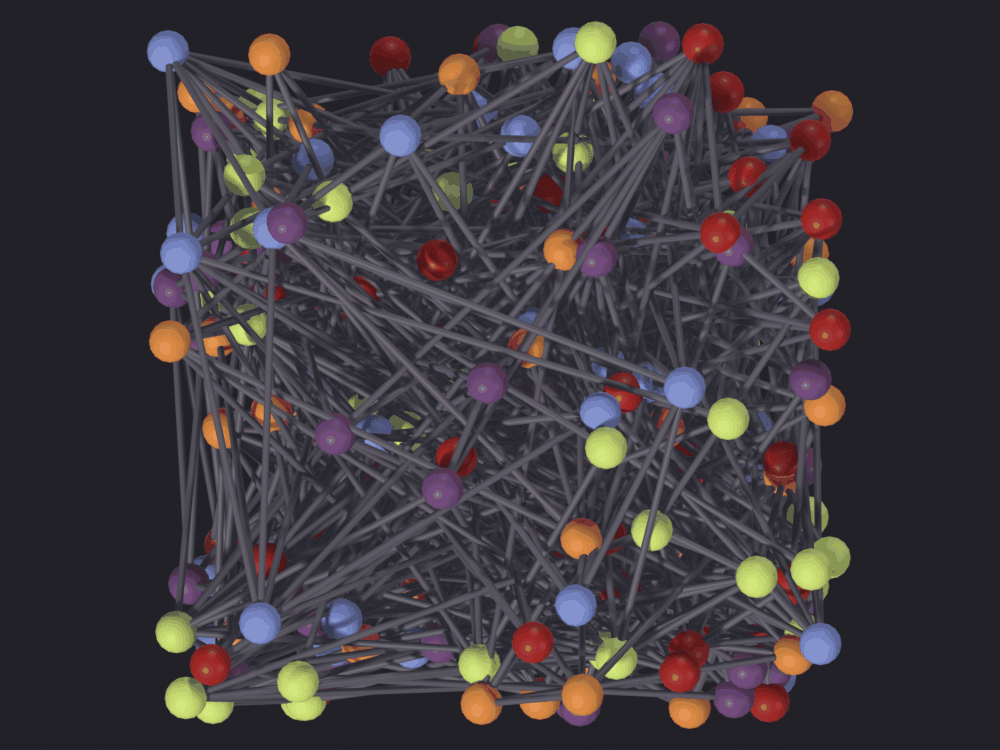

[PASS] 1_as_it_arrives.png legible — 55.2% ink (healthy range 0.5–60%)


In [10]:
draw(graph, "renders/14_layouts/1_as_it_arrives",
     look='ink', color_attribute="node_block")

The graph as the mesh builder left it: 240 nodes at random
positions in a cube, 840 edges between them, every group spread across the
whole frame. The control the rest of the notebook is measured against.

## 2 · The menu behind one enum

`bpy.ops.scigraphs.apply_layout(algorithm=...)` accepts thirty-two values.
They belong to five families that answer different questions, and three of
the entries are not layouts of the graph at all.

In [11]:
FAMILIES = {
    "force-directed": ['SPRING', 'SPRING_3D', 'FORCEATLAS2', 'IGRAPH_FR',
                       'IGRAPH_DRL', 'IGRAPH_DRL_2D', 'IGRAPH_LGL',
                       'IGRAPH_DH', 'IGRAPH_GRAPHOPT', 'YIFAN_HU',
                       'GRAPHVIZ_NEATO', 'GRAPHVIZ_FDP', 'GRAPHVIZ_SFDP'],
    "stress / spectral": ['IGRAPH_KK', 'SPECTRAL_3D', 'MDS_3D'],
    "hierarchical": ['GRAPHVIZ_DOT', 'SUGIYAMA', 'HIERARCHICAL_3D',
                     'CIRCULAR_HIERARCHY', 'BIPARTITE_3D', 'GRAPHVIZ_TWOPI'],
    "circular / packing": ['GRAPHVIZ_CIRCO', 'CIRCLE_PACKING',
                           'GRAPHVIZ_OSAGE', 'GRAPHVIZ_PATCHWORK'],
    "geometric (ignores the edges)": ['RANDOM', 'GRID', 'SPHERE', 'SPIRAL_3D',
                                      'HELIX', 'CUBE'],
}

listed = {item for group in FAMILIES.values() for item in group}
enum = {item.identifier for item in
        bpy.ops.scigraphs.apply_layout.get_rna_type()
        .properties["algorithm"].enum_items}

print(f"{'family':<32} {'n':>3}  what it is optimizing")
print("-" * 78)
for family, members in FAMILIES.items():
    print(f"{family:<32} {len(members):>3}")
print()
print("in the enum but unclassified:", sorted(enum - listed) or "none")
print("classified but not in the enum:", sorted(listed - enum) or "none")

check("every algorithm in the enum is accounted for",
      listed == enum, f"{len(enum)} entries")

family                             n  what it is optimizing
------------------------------------------------------------------------------
force-directed                    13
stress / spectral                  3
hierarchical                       6
circular / packing                 4
geometric (ignores the edges)      6

in the enum but unclassified: none
classified but not in the enum: none
[PASS] every algorithm in the enum is accounted for — 32 entries


True

The last family is the one to be careful with. `SPHERE`,
`HELIX`, `SPIRAL_3D`, `GRID` and `RANDOM` never read an edge: they place node
*i* by *i* and the node count. They are legitimate (a sphere of nodes with
edges drawn between them shows that a graph is dense) but a figure made with
one cannot support a claim about structure, and section 4 shows one of them
scoring well for a reason that has nothing to do with the graph.

### What is actually installed

Several branches are optional and fall back silently. The operator reports
`FINISHED` either way and the only trace is a console line.

In [12]:
from scigraphs_core.mesh.layouts import common as layout_common
from scigraphs_core.mesh.layouts import forceatlas as layout_fa2

print(f"igraph available          : {layout_common.IGRAPH_AVAILABLE}")
print(f"scigraphs-utils (Graphviz): {layout_common.GRAPHVIZ_AVAILABLE}")
print(f"fa2 package               : {layout_common.FA2_AVAILABLE}")
print(f"networkx forceatlas2      : {layout_fa2.NX_FA2 is not None}")

check("igraph is present", layout_common.IGRAPH_AVAILABLE,
      "without it, nine algorithms silently become Spring 2D")
check("the Graphviz backend is present", layout_common.GRAPHVIZ_AVAILABLE,
      "without it, YIFAN_HU and the eight GRAPHVIZ_* entries fail")

igraph available          : True
scigraphs-utils (Graphviz): True
fa2 package               : False
networkx forceatlas2      : True
[PASS] igraph is present — without it, nine algorithms silently become Spring 2D
[PASS] the Graphviz backend is present — without it, YIFAN_HU and the eight GRAPHVIZ_* entries fail


True

> **Add-on defect: a fallback that is announced but does not
> happen.** `FORCEATLAS2` is the scene default (`layout_algorithm`), and the
> optional `fa2` package is not installed in Blender's Python. The dispatcher
> treats that as a fallback and labels the run so
> (`SciGraphs/core/mesh/layouts/dispatcher.py:58`), printing
>
> ```
> Computing ForceAtlas2 (3D, networkx) for 240 nodes...
> Layout algorithm: FORCEATLAS2
> Fallback: using SPRING (2D fallback) instead
>    Reason: FORCEATLAS2 library not available
> ```
>
> The first line is the true one: what ran was ForceAtlas2, in 3D.
> `_forceatlas2_layout` prefers `nx.forceatlas2_layout`, which networkx has
> had since 3.4 (`SciGraphs/core/mesh/layouts/forceatlas.py:24`), and drops
> to Spring 2D only when *neither* backend exists. The label is checked
> against `FA2_AVAILABLE` alone, never against what the function chose. The
> same test guards the nine `IGRAPH_*` branches, where it is correct because
> those do fall through.

> The object cannot be asked either: the import path stamps
> `obj["auto_layout_algorithm"] = props.layout_algorithm`
> (`SciGraphs/ui/operators/scigraphs/data_operators.py:42`), the algorithm
> *requested*. A graph laid out by a fallback carries the name of the
> algorithm that was not available.

## 3 · Is a layout a function of the graph?

Before comparing seven layouts, is *one* layout a stable thing? A force
layout starts from random positions, and the machinery is there:
`apply_graph_layout` opens by calling `_reset_layout_rng()`, which seeds a
module-level `RandomState` from `repro.determinism.get_layout_seed()`.

Each algorithm runs three times rather than twice, because one of the results
below is that the *first* run differs from every later one.

In [13]:
def positions(obj):
    """The layout's node positions as an (n, 3) array. A **copy**.

    `np.asarray` would not do. A Blender ID property array supports the buffer
    protocol, so `asarray` hands back a *view* onto Blender's own memory, and
    Blender reuses that allocation when the property is overwritten with a list
    of the same length. Two "before and after" snapshots taken that way are the
    same object, every difference between them is exactly zero, and nothing
    raises.
    """
    return np.array(obj["node_positions"], dtype=np.float64).reshape(-1, 3)


def apply(obj, algorithm, iterations=100, scale=5.0, **kwargs):
    """`bpy.ops.scigraphs.apply_layout`, timed, quiet, returning positions."""
    sg.graphs.activate(obj)
    started = time.time()
    with nb.quiet():
        result = bpy.ops.scigraphs.apply_layout(
            algorithm=algorithm, iterations=iterations, scale=scale, **kwargs)
    elapsed = time.time() - started
    if 'FINISHED' not in result:
        return None, elapsed
    return positions(obj), elapsed


# YIFAN_HU before GRAPHVIZ_SFDP: same Graphviz engine, and only whichever runs
# first in the process sees what section 3.1 describes.
REPEATED = ['GRID', 'RANDOM', 'SPHERE', 'CUBE', 'FORCEATLAS2', 'SPRING_3D',
            'IGRAPH_FR', 'IGRAPH_KK', 'SPECTRAL_3D', 'MDS_3D', 'YIFAN_HU',
            'GRAPHVIZ_SFDP', 'GRAPHVIZ_DOT']

repeats = {}
for algorithm in REPEATED:
    runs = []
    for _ in range(3):
        pos, _elapsed = apply(graph, algorithm)
        runs.append(pos)
    if any(r is None for r in runs):
        repeats[algorithm] = None
        continue
    repeats[algorithm] = {
        "xy_1v2": float(np.abs(runs[0][:, :2] - runs[1][:, :2]).max()),
        "xy_2v3": float(np.abs(runs[1][:, :2] - runs[2][:, :2]).max()),
        "z_1v2": float(np.abs(runs[0][:, 2] - runs[1][:, 2]).max()),
        "z_2v3": float(np.abs(runs[1][:, 2] - runs[2][:, 2]).max()),
        "extent": float(np.linalg.norm(runs[2].max(axis=0) - runs[2].min(axis=0))),
    }

print(f"{'algorithm':<16}{'extent':>9}{'xy 1v2':>10}{'xy 2v3':>10}"
      f"{'z 1v2':>9}{'z 2v3':>9}   verdict")
print("-" * 78)
for algorithm, r in repeats.items():
    if r is None:
        print(f"{algorithm:<16}{'-':>9}   did not finish")
        continue
    worst_later = max(r["xy_2v3"], r["z_2v3"])
    worst_first = max(r["xy_1v2"], r["z_1v2"])
    if worst_first <= 1e-9:
        verdict = "repeats"
    elif worst_later <= 1e-9:
        verdict = "repeats from the 2nd run on"
    else:
        verdict = "does not repeat"
    print(f"{algorithm:<16}{r['extent']:9.2f}{r['xy_1v2']:10.4f}"
          f"{r['xy_2v3']:10.4f}{r['z_1v2']:9.4f}{r['z_2v3']:9.4f}   {verdict}")


Layout algorithm: GRID
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: GRID
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.001s
Status: success

Info: Layout 'GRID' applied

Layout algorithm: GRID
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: GRID
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.001s
Status: success

Info: Layout 'GRID' applied

Layout algorithm: GRID
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: GRID
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.001s
Status: success

Info: Layout 'GRID' applied

Layout algorithm: RANDOM
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: RANDOM
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.001s
Status: success

Info: Layout 'RANDOM' applied

Layout algorithm: RANDOM
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: R

Three behaviors, only one of which the seeding machinery
promises.

**Deterministic.** `GRID`, `SPHERE`, `IGRAPH_KK`, `SPECTRAL_3D`, `MDS_3D`,
`GRAPHVIZ_DOT` and `RANDOM` return the same coordinates every time. The first
six have no random component: Kamada-Kawai is stress majorization from a
deterministic start, spectral and MDS are eigendecompositions, `dot` a
layered sweep. `RANDOM` is random *and* reproducible: it draws from
`get_layout_seed()` through `_random_layout`, a fixed function of the seed.

**`FORCEATLAS2` is the only force layout here that repeats**, and the only
one that consults the module RNG the dispatcher just reset:
`forceatlas.py:39` passes `seed=_get_layout_rng().randint(...)` into
networkx. Everything else in the family ignores it, so the same algorithm on
the same graph with the same parameters twice leaves the nodes elsewhere.

> **Add-on defect: the layout RNG is reset and then not used.**
> `apply_graph_layout` calls `_reset_layout_rng()` on entry
> (`SciGraphs/core/mesh/layouts/dispatcher.py:22`), which builds
> `np.random.RandomState(get_layout_seed())` and stores it in a module global,
> **not** in the *global* NumPy random state. But `_spring_layout_2d` and
> `_spring_layout_3d` call `nx.spring_layout(G, ...)` with no `seed=` argument
> (`SciGraphs/core/mesh/layouts/networkx_layouts.py:8` and `:18`), so networkx
> falls back to the global state and reads a different generator from the one
> prepared. The same holds for `_igraph_*` (igraph has its own RNG, never
> seeded here) and for `_cube_layout`, which fills the interior with a bare
> `np.random.rand` (`SciGraphs/core/mesh/layouts/basic.py:121`).

> **Add-on defect: the reproducibility registry advertises a `seed`
> parameter the operator does not have.** `scigraphs.apply_layout` is
> registered with a `seed` property mapping
> (`SciGraphs/core/repro/registry.py:251-258`), but neither the operator nor
> `LAYOUT_PROPERTIES` defines one. A pipeline spec that sets `seed` on a
> layout step documents a seed nothing reads, and the manifest still looks
> right.

### 3.1 · The first Graphviz sfdp call in a session is the odd one

`YIFAN_HU` and `GRAPHVIZ_SFDP` are the same Graphviz engine; `YIFAN_HU` is
`sfdp` with a generated Z. In the table above the first of the two to run
differs between its first and second call and is then stable forever, while
the second is stable from its own first call. The engine is passed a fixed
`start` seed (`yifan_hu.py:108`), so this is state inside the bundled
Graphviz that survives across calls and is initialized on the first.

So **a script that lays a graph out with `sfdp` once, saves the figure and
exits, produces a figure that no later run of the same script reproduces.**
`neato`, `twopi` and `dot` do not do this; measured over three calls each in
a fresh Blender, they are identical from the start.

In [14]:
first_call = {k: repeats[k] for k in ('YIFAN_HU', 'GRAPHVIZ_SFDP')
              if repeats.get(k)}
for name, r in first_call.items():
    print(f"{name:<16} xy first-vs-second {r['xy_1v2']:8.4f}   "
          f"second-vs-third {r['xy_2v3']:8.4f}")

check("sfdp settles down after its first call in the process",
      all(r["xy_2v3"] <= 1e-9 for r in first_call.values()),
      "the XY of the first call is the one that differs")

YIFAN_HU         xy first-vs-second   5.0587   second-vs-third   0.0000
GRAPHVIZ_SFDP    xy first-vs-second   0.0000   second-vs-third   0.0000
[PASS] sfdp settles down after its first call in the process — the XY of the first call is the one that differs


True

`YIFAN_HU` has a second source of variation, in Z only. Its
default dimension mode is `2Z`: a 2D `sfdp` layout with the third coordinate
from the graph's Laplacian spectrum (`sfdp_z_method='SPECTRAL'`), through
`scipy.sparse.linalg.eigsh`, which starts from a random vector and returns an
eigenvector whose **sign is arbitrary**. So the Z axis flips between runs,
visible above as a Z difference that never settles while XY does. Set
`sfdp_dim='2'` for a flat, fully repeatable version.

In [15]:
flat_runs = [apply(graph, 'YIFAN_HU', sfdp_dim='2')[0] for _ in range(2)]
check("YIFAN_HU with sfdp_dim='2' repeats exactly",
      float(np.abs(flat_runs[0] - flat_runs[1]).max()) <= 1e-9)

Computing Yifan Hu layout for 240 nodes...
  mode=2, backend=scigraphs-utils, engine=sfdp
  scigraphs-utils Graphviz sfdp computed 240 nodes
  Final ranges (scale=5.0): X=5.0, Y=4.8, Z=0.0
  Yifan Hu (scigraphs-utils sfdp, mode=2) completed in 0.03s

Layout algorithm: YIFAN_HU
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: YIFAN_HU
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.034s
Status: success

Info: Layout 'YIFAN_HU' applied
Computing Yifan Hu layout for 240 nodes...
  mode=2, backend=scigraphs-utils, engine=sfdp
  scigraphs-utils Graphviz sfdp computed 240 nodes
  Final ranges (scale=5.0): X=5.0, Y=4.8, Z=0.0
  Yifan Hu (scigraphs-utils sfdp, mode=2) completed in 0.03s

Layout algorithm: YIFAN_HU
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: YIFAN_HU
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.033s
Status: success

Info: Layout 'YIFAN_HU' applied
[PASS] YIFAN_HU with

True

### 3.2 · What a seed is worth, and what it is not

The workaround for everything in the "does not repeat" column is to seed the
*global* NumPy state, which `repro.determinism.set_pipeline_seed()` does as a
side effect; it is what the pipeline executor of notebook 19 calls before a
run. Call it before **each** layout: `apply_graph_layout` does not restore
it.

In [16]:
def unit(pos):
    """Center on the origin and scale to unit RMS radius.

    A force layout has no natural size, so comparing two runs in Blender units
    compares an artifact.
    """
    pos = pos - pos.mean(axis=0)
    rms = float(np.sqrt((pos ** 2).sum(axis=1).mean()))
    return pos / (rms if rms > 0 else 1.0)


seeded = {}
for seed in (1234, 99):
    determinism.set_pipeline_seed(seed)
    seeded[seed] = apply(graph, 'SPRING_3D')[0]
determinism.set_pipeline_seed(1234)
repeat_1234 = apply(graph, 'SPRING_3D')[0]
determinism.set_pipeline_seed(None)

check("the same pipeline seed gives the same layout",
      float(np.abs(seeded[1234] - repeat_1234).max()) <= 1e-9,
      "set_pipeline_seed seeds the global NumPy state that "
      "nx.spring_layout actually reads")
check("a different pipeline seed gives a different layout",
      float(np.abs(seeded[1234] - seeded[99]).max()) > 1e-6)


Layout algorithm: SPRING_3D
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: SPRING_3D
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.136s
Status: success

Info: Layout 'SPRING_3D' applied

Layout algorithm: SPRING_3D
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: SPRING_3D
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.138s
Status: success

Info: Layout 'SPRING_3D' applied

Layout algorithm: SPRING_3D
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: SPRING_3D
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.138s
Status: success

Info: Layout 'SPRING_3D' applied
[PASS] the same pipeline seed gives the same layout — set_pipeline_seed seeds the global NumPy state that nx.spring_layout actually reads
[PASS] a different pipeline seed gives a different layout


True

**How different?** A force layout is defined only up to a rigid
motion: nothing in the objective distinguishes a layout from the same layout
rotated, reflected or translated, so the raw distance between two runs counts
a rotation as a disagreement. Aligning one onto the other first (orthogonal
Procrustes) separates a different arrangement from a different camera angle.

In [17]:
from scipy.linalg import orthogonal_procrustes

A, B = unit(seeded[1234]), unit(seeded[99])
rotation, _scale = orthogonal_procrustes(B, A)
aligned = B @ rotation
residual = np.linalg.norm(aligned - A, axis=1)

raw = np.linalg.norm(A - B, axis=1)
upper = np.triu_indices(len(A), 1)
d_A = np.linalg.norm(A[:, None, :] - A[None, :, :], axis=-1)[upper]
d_B = np.linalg.norm(B[:, None, :] - B[None, :, :], axis=-1)[upper]

print(f"raw median displacement        {np.median(raw):.3f}  (RMS radii)")
print(f"after alignment                {np.median(residual):.3f}"
      f"   worst node {residual.max():.3f}")
print(f"pairwise-distance correlation  {np.corrcoef(d_A, d_B)[0, 1]:.3f}")

put_attribute(graph, "node_shift", residual)

raw median displacement        1.589  (RMS radii)
after alignment                0.496   worst node 2.115
pairwise-distance correlation  0.842


'node_shift'

Two thirds of the apparent motion between the two seeds is
rigid rotation. What is left is a genuinely different arrangement: a median
residual of about half an RMS radius, worst node twice that. The pairwise
distances still agree at r = 0.84. A seed changes the picture substantially
and the *relations between the nodes* rather less.

Below: the run at seed 1234, colored by how far each node ended up from
where seed 99 put it, after alignment. The top 2 % is clipped, as everywhere
in this suite.

Info: Geometry Nodes modifier added
Info: Attribute -> node_shift  ·  node_shift -> turbo [log]  [0.02009 … 1.505] on Point


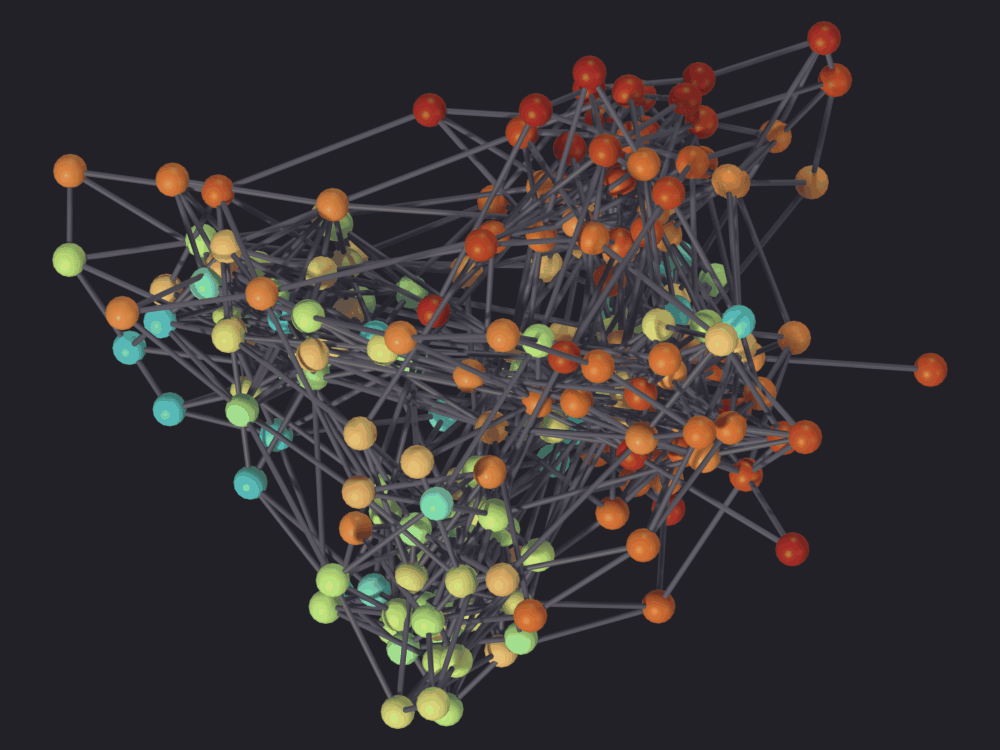

[PASS] 2_seed_residual.png legible — 33.2% ink (healthy range 0.5–60%)


In [18]:
draw(graph, "renders/14_layouts/2_seed_residual",
     look='ink', color_attribute="node_shift", clip_high_pct=98)

**The caption has to be checked against the numbers: the first
one written for this figure was wrong.** It said the block interiors barely
move and the residual concentrates on the nodes bridging two blocks, which is
what the picture looks like and a plausible story (a node with fewer ties has
less telling it where to go). It is not what the data says.

In [19]:
loyalty = np.array([
                   sum(1 for v in G.neighbors(u) if block[v] == block[u]) / max(G.degree(u), 1)
                   for u in G.nodes()])
bridging = loyalty < np.median(loyalty)

print(f"residual vs in-block neighbor fraction  : "
      f"{np.corrcoef(residual, loyalty)[0, 1]:+.3f}")
print(f"residual vs degree                      : "
      f"{np.corrcoef(residual, degree)[0, 1]:+.3f}")
print(f"median residual, bridging nodes         : "
      f"{np.median(residual[bridging]):.3f}")
print(f"median residual, block-interior nodes   : "
      f"{np.median(residual[~bridging]):.3f}")

check("the residual is not concentrated on the bridging nodes",
      np.median(residual[bridging]) <= np.median(residual[~bridging]),
      "the opposite of what the figure appears to show")

residual vs in-block neighbor fraction  : +0.181
residual vs degree                      : -0.134
median residual, bridging nodes         : 0.483
median residual, block-interior nodes   : 0.509
[PASS] the residual is not concentrated on the bridging nodes — the opposite of what the figure appears to show


True

The two medians differ by five percent, in the *other*
direction: a bridging node moves marginally less than one inside a block.
Neither correlation printed above reaches 0.2 in absolute value, a few per
cent of the variance between them. The only one pointing somewhere sensible
is degree, which is negative: a node with more edges is more constrained and
settles in more nearly the same place.

What the eye reads as structure is a smooth gradient across the frame, which
is what an alignment residual looks like when a rigid rotation has been
removed from something that was not related by one. An artifact of the
comparison, not a property of the nodes. The figure is kept because a
colored field can look organized, support a sentence that sounds right, and
mean nothing.

### 3.3 · What survives the seed

If the picture moves and the relations do not, measure the relations: the
mean distance between two nodes of the same block divided by the mean
distance between two nodes of different blocks. Below 1 means the layout put
the blocks together; 1 means it did not.

In [20]:
def block_ratio(pos, groups):
    """Within-group over between-group mean distance, on unit-RMS positions."""
    pos = unit(pos)
    d = np.linalg.norm(pos[:, None, :] - pos[None, :, :], axis=-1)
    same = groups[:, None] == groups[None, :]
    np.fill_diagonal(same, False)
    return float(d[same].mean() / d[~same].mean())


for seed, pos in seeded.items():
    print(f"pipeline seed {seed:<6} block ratio {block_ratio(pos, block):.3f}")

ratios = [block_ratio(pos, block) for pos in seeded.values()]
check("the finding survives the seed even though the figure does not",
      abs(ratios[0] - ratios[1]) < 0.02,
      f"{ratios[0]:.3f} vs {ratios[1]:.3f}")

pipeline seed 1234   block ratio 0.451
pipeline seed 99     block ratio 0.447
[PASS] the finding survives the seed even though the figure does not — 0.451 vs 0.447


True

The rule for seeds: **quote the measurement, publish the seed,
and do not build an argument on the shape of the picture.** Two runs of the
same force layout agree on the answer to four decimal places and disagree
about where everything is.

## 4 · Seven layouts, one graph

Everything except the algorithm is held fixed: the same object, the same 240
nodes and 840 edges, `scale=5.0` and `iterations=100`, the same look,
attribute and camera. Each run overwrites the previous one's positions on the
*same* mesh, so nothing else can have drifted between panels. One per family,
plus two controls:

| panel | family | what it optimizes |
|---|---|---|
| `RANDOM` | geometric | nothing; the control |
| `IGRAPH_FR` | force-directed | edge length against node repulsion, in 3D |
| `YIFAN_HU` | force-directed, multilevel | the same, coarsened (Graphviz `sfdp`) |
| `IGRAPH_KK` | stress | drawn distance against graph distance |
| `SPECTRAL_3D` | spectral | the Laplacian's low eigenvectors |
| `GRAPHVIZ_DOT` | hierarchical | layers, then crossings within a layer |
| `SPHERE` | geometric | nothing; node *i* goes to point *i* of a Fibonacci sphere |

Four numbers go with each panel: extent and median NN, the size of the result
and the typical spacing inside it in Blender units (why the node radius is
re-derived per panel); block ratio, the measure from section 3.3; and hidden,
the fraction of nodes a top-down view puts behind another node (section 6).


Layout algorithm: RANDOM
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: RANDOM
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.001s
Status: success

Info: Layout 'RANDOM' applied
RANDOM  0.00 s
Info: Geometry Nodes modifier added
Info: Attribute -> node_block  ·  node_block -> turbo [log]  [0 … 4] on Point


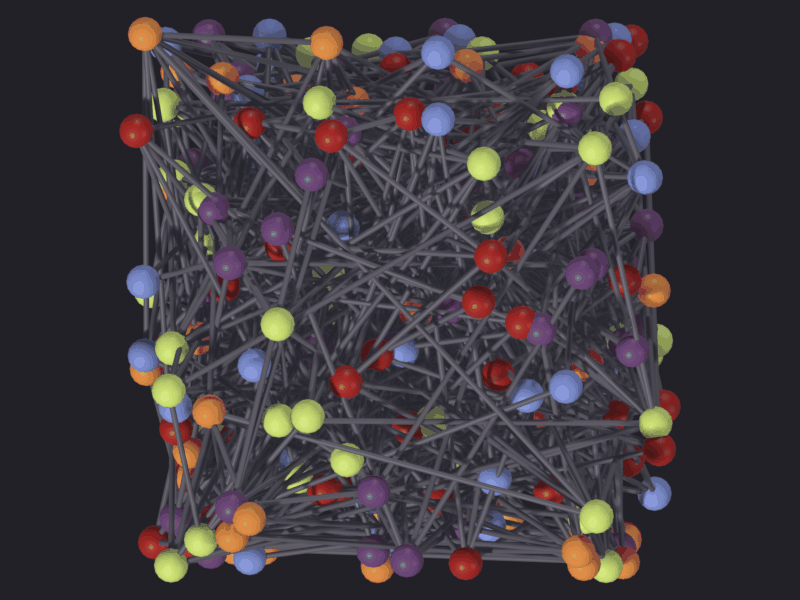

[PASS] 3_random.png legible — 56.0% ink (healthy range 0.5–60%)
Computing igraph Fruchterman-Reingold layout for 240 nodes...
  Fruchterman-Reingold completed in 0.01s

Layout algorithm: IGRAPH_FR
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: IGRAPH_FR
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.012s
Status: success

Info: Layout 'IGRAPH_FR' applied
IGRAPH_FR  0.02 s
Info: Geometry Nodes modifier added
Info: Attribute -> node_block  ·  node_block -> turbo [log]  [0 … 4] on Point


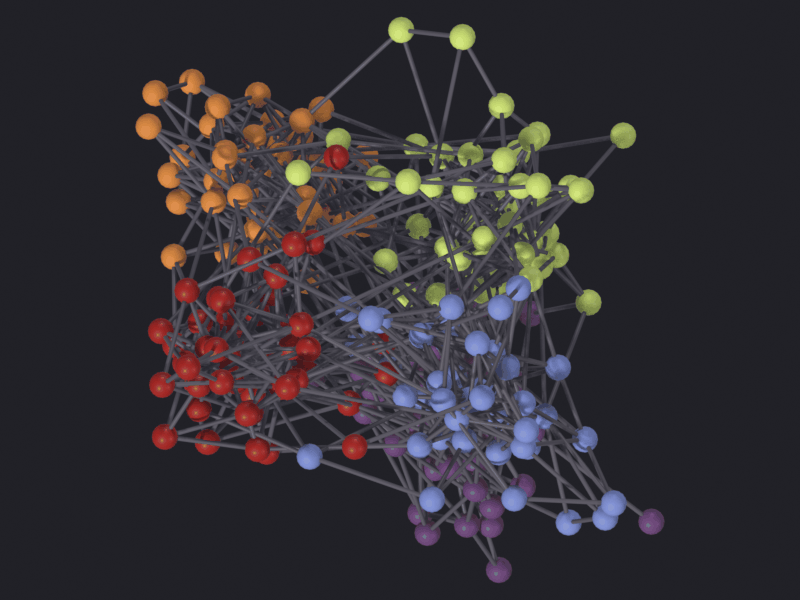

[PASS] 3_igraph_fr.png legible — 30.2% ink (healthy range 0.5–60%)
Computing Yifan Hu layout for 240 nodes...
  mode=2Z, backend=scigraphs-utils, engine=sfdp
  z_method=SPECTRAL, z_scale=0.30000001192092896
  Generated Graphviz Z via SPECTRAL: -0.750 to 0.212
  scigraphs-utils Graphviz sfdp computed 240 nodes
  Z range: -0.750 to 0.212
  Final ranges (scale=5.0): X=5.0, Y=4.8, Z=1.0
  Yifan Hu (scigraphs-utils sfdp, mode=2Z) completed in 0.04s

Layout algorithm: YIFAN_HU
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: YIFAN_HU
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.037s
Status: success

Info: Layout 'YIFAN_HU' applied
YIFAN_HU  0.04 s
Info: Geometry Nodes modifier added
Info: Attribute -> node_block  ·  node_block -> turbo [log]  [0 … 4] on Point


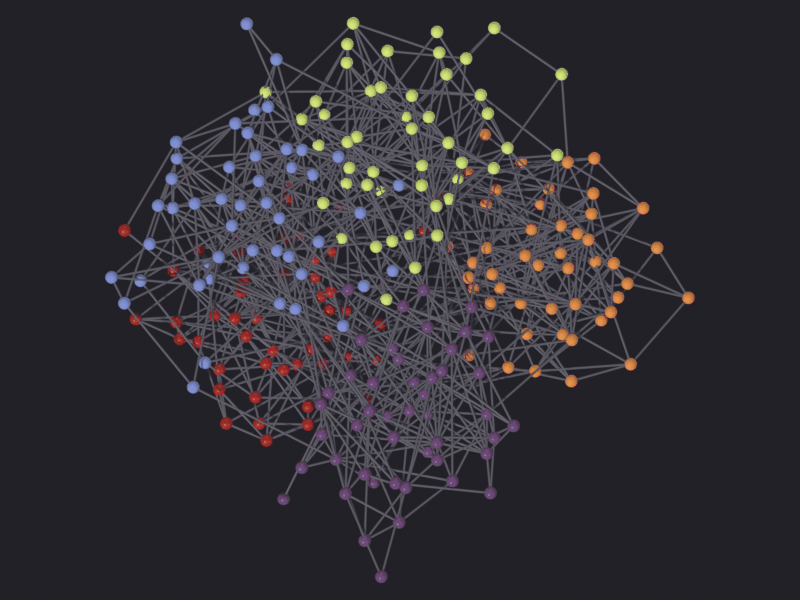

[PASS] 3_yifan_hu.png legible — 26.6% ink (healthy range 0.5–60%)
Computing igraph Kamada-Kawai layout for 240 nodes...
  Kamada-Kawai completed in 0.05s

Layout algorithm: IGRAPH_KK
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: IGRAPH_KK
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.057s
Status: success

Info: Layout 'IGRAPH_KK' applied
IGRAPH_KK  0.06 s
Info: Geometry Nodes modifier added
Info: Attribute -> node_block  ·  node_block -> turbo [log]  [0 … 4] on Point


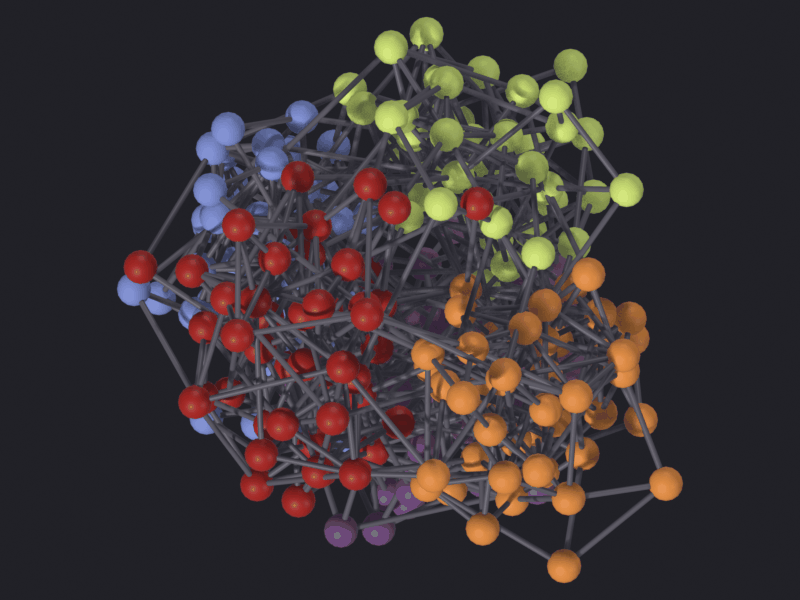

[PASS] 3_igraph_kk.png legible — 38.1% ink (healthy range 0.5–60%)
Computing Spectral 3D layout for 240 nodes...
  Spectral 3D completed in 0.03s

Layout algorithm: SPECTRAL_3D
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: SPECTRAL_3D
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.034s
Status: success

Info: Layout 'SPECTRAL_3D' applied
SPECTRAL_3D  0.04 s
Info: Geometry Nodes modifier added
Info: Attribute -> node_block  ·  node_block -> turbo [log]  [0 … 4] on Point


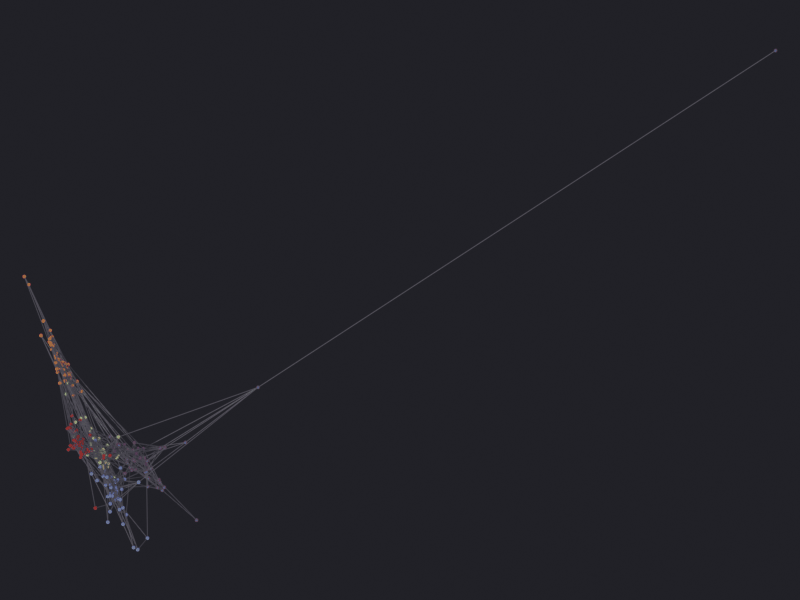

[PASS] 3_spectral_3d.png legible — 2.1% ink (healthy range 0.5–60%)
  scigraphs-utils Graphviz dot computed 240 nodes

Layout algorithm: GRAPHVIZ_DOT
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: GRAPHVIZ_DOT
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.446s
Status: success

Info: Layout 'GRAPHVIZ_DOT' applied
GRAPHVIZ_DOT  0.45 s
Info: Geometry Nodes modifier added
Info: Attribute -> node_block  ·  node_block -> turbo [log]  [0 … 4] on Point


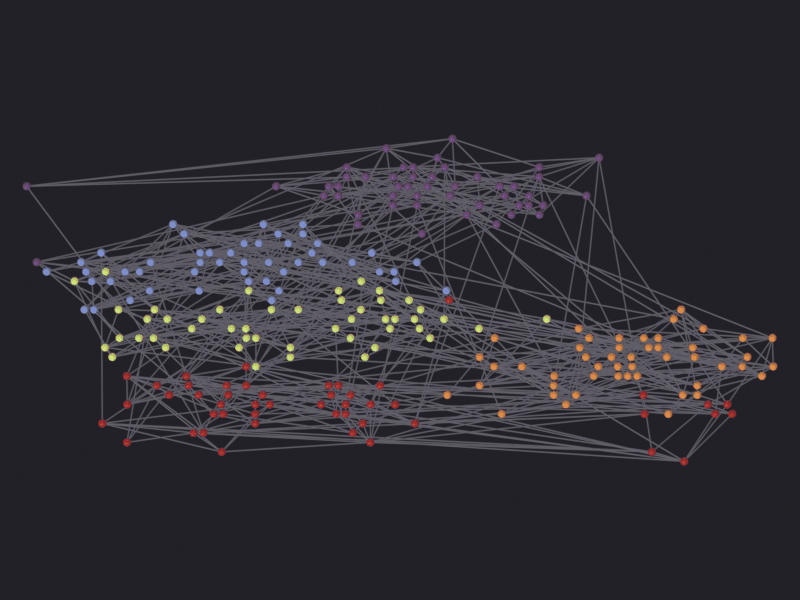

[PASS] 3_graphviz_dot.png legible — 23.9% ink (healthy range 0.5–60%)

Layout algorithm: SPHERE
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: SPHERE
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.001s
Status: success

Info: Layout 'SPHERE' applied
SPHERE  0.01 s
Info: Geometry Nodes modifier added
Info: Attribute -> node_block  ·  node_block -> turbo [log]  [0 … 4] on Point


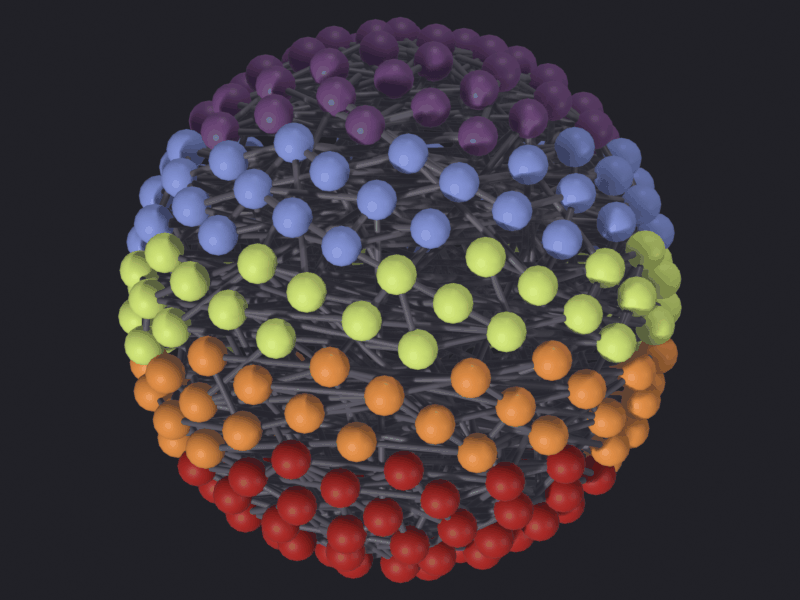

[PASS] 3_sphere.png legible — 48.7% ink (healthy range 0.5–60%)


In [21]:
def plan_occlusion(pos, radius):
    """Fraction of nodes covered by a nearer one in a top-down projection."""
    order = np.argsort(-pos[:, 2])
    xy = pos[:, :2]
    hidden = 0
    for rank in range(1, len(order)):
        node = order[rank]
        above = order[:rank]
        if (np.linalg.norm(xy[above] - xy[node], axis=1) < radius).any():
            hidden += 1
    return hidden / len(pos)


def z_share(pos):
    """Share of the layout's spread carried by its third principal axis."""
    pos = pos - pos.mean(axis=0)
    singular = np.linalg.svd(pos, full_matrices=False)[1]
    return float(singular[2] / singular.sum())


PANELS = ['RANDOM', 'IGRAPH_FR', 'YIFAN_HU', 'IGRAPH_KK', 'SPECTRAL_3D',
          'GRAPHVIZ_DOT', 'SPHERE']

panel_stats = {}
for algorithm in PANELS:
    pos, elapsed = apply(graph, algorithm)
    if pos is None:
        print(f"{algorithm}: did not finish")
        continue
    (_center, _size, diagonal, median_nn), _source = sg.render.measure(graph)
    radius = median_nn * sg.render.NODE_FRACTION
    panel_stats[algorithm] = {
        "seconds": elapsed, "extent": diagonal, "median_nn": median_nn,
        "radius": radius, "ratio": block_ratio(pos, block),
        "hidden": plan_occlusion(pos, radius), "z_share": z_share(pos),
    }
    print(f"{algorithm}  {elapsed:.2f} s")
    draw(graph, f"renders/14_layouts/3_{algorithm.lower()}",
         resolution=(800, 600), width=700,
         look='ink', color_attribute="node_block")

In [22]:
print(f"{'algorithm':<14}{'s':>7}{'extent':>9}{'median NN':>11}"
      f"{'radius':>9}{'block ratio':>13}{'hidden':>8}{'z share':>9}")
print("-" * 80)
for algorithm, s in panel_stats.items():
    print(f"{algorithm:<14}{s['seconds']:7.2f}{s['extent']:9.2f}"
          f"{s['median_nn']:11.4f}{s['radius']:9.4f}{s['ratio']:13.3f}"
          f"{s['hidden']:8.3f}{s['z_share']:9.3f}")

check("the random control finds no structure",
      abs(panel_stats['RANDOM']['ratio'] - 1.0) < 0.05,
      f"block ratio {panel_stats['RANDOM']['ratio']:.3f}")
check("the force layouts do",
      panel_stats['IGRAPH_FR']['ratio'] < 0.6
      and panel_stats['YIFAN_HU']['ratio'] < 0.6)

algorithm           s   extent  median NN   radius  block ratio  hidden  z share
--------------------------------------------------------------------------------
RANDOM           0.00     8.59     0.4560   0.1596        1.003   0.275    0.304
IGRAPH_FR        0.02   125.04     5.2033   1.8212        0.448   0.267    0.291
YIFAN_HU         0.04     6.99     0.1562   0.0547        0.493   0.000    0.035
IGRAPH_KK        0.06   132.87     6.7399   2.3590        0.527   0.354    0.312
SPECTRAL_3D      0.04     7.52     0.0366   0.0128        0.373   0.192    0.333
GRAPHVIZ_DOT     0.45     5.45     0.0779   0.0273        0.507   0.000    0.000
SPHERE           0.01    17.27     1.1024   0.3858        0.753   0.362    0.333
[PASS] the random control finds no structure — block ratio 1.003
[PASS] the force layouts do


True

### Is the color keeping up?

`sg.render.material()` declines to overwrite an existing
`<obj>_SciGraphsColor` material (`notebooks/tools/sg.render.py:736-740`) and
rewires whichever color layer it finds (`:759-765`), so an object colored
once can keep that coloring through a later render that asked for a
different attribute. `nb.ink()` cannot see the difference, because the same
nodes are lit either way.

The panels above all use one attribute; the risk is in the rest of the
notebook, which recolors this same object by `node_shift`, `node_late_move`
and `node_degree` in turn. Two renders of **one** layout under two
attributes, compared pixel by pixel, settle it.

In [23]:
apply(graph, 'IGRAPH_FR')
margin = framing_margin(graph, (400, 300))
by_block = nb.render(
    graph, "renders/14_layouts/_color_check_block", resolution=(400, 300),
    look='ink', color_attribute="node_block", margin=margin,
    shrink=False, verbose=False)
by_degree = nb.render(
    graph, "renders/14_layouts/_color_check_degree", resolution=(400, 300),
    look='ink', color_attribute="node_degree", margin=margin,
    shrink=False, verbose=False)

changed = sg.render.differing_fraction(by_degree, by_block)
ink_block, ink_degree = nb.ink(by_block), nb.ink(by_degree)
print(f"ink, colored by block  : {ink_block:.4f}")
print(f"ink, colored by degree : {ink_degree:.4f}   "
      f"(apart by {abs(ink_block - ink_degree) / ink_block:.1%}; the same "
      f"nodes are lit either way, so this cannot be the check)")
print(f"pixels that actually changed color: {changed:.1%}")

check("the graph really is recolored between renders",
      changed > 0.05,
      "a stale material would leave this near zero while every other "
      "number in the render stayed healthy")

Computing igraph Fruchterman-Reingold layout for 240 nodes...
  Fruchterman-Reingold completed in 0.01s

Layout algorithm: IGRAPH_FR
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: IGRAPH_FR
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.011s
Status: success

Info: Layout 'IGRAPH_FR' applied
Info: Geometry Nodes modifier added
Info: Attribute -> node_block  ·  node_block -> turbo [log]  [0 … 4] on Point
Info: Geometry Nodes modifier added
Info: Attribute -> node_degree  ·  node_degree -> turbo [log]  [1 … 14] on Point
ink, colored by block  : 0.4175
ink, colored by degree : 0.4189   (apart by 0.3%; the same nodes are lit either way, so this cannot be the check)
pixels that actually changed color: 17.1%
[PASS] the graph really is recolored between renders — a stale material would leave this near zero while every other number in the render stayed healthy


True

### Reading the panels

**The control is the densest figure here.** `RANDOM` reaches 57 % ink, three
points under the ceiling `check_render` allows, and its block ratio is 1.003:
the groups are neither together nor apart. Everything the other six panels
show, they added.

**`scale=5.0` does not mean the same thing twice.** Extents run from 5.4
Blender units (`GRAPHVIZ_DOT`) to 140 (`IGRAPH_FR`, `IGRAPH_KK`), a factor of
twenty-six; median spacing from 0.037 to 6.7, a factor of a hundred and
eighty. The Graphviz and geometric layouts normalize to the requested scale;
the igraph ones multiply igraph's own output by it (`igraph_layouts.py:37`,
`:70`), and that output is whatever its simulation reached. Hence a scale
slider with no visible effect, and a node radius derived per panel: at a
fixed radius, five of these seven are either a solid mat or a field of specks.

**`SPECTRAL_3D` spends the whole frame on one node.** Its block ratio is the
best of the seven at 0.373 and its figure is nearly empty:
`nx.spectral_layout` normalizes by the extreme coordinate, one node sits far
out on the second eigenvector, and the rest are compressed into a corner. The
median nearest-neighbor distance is 0.037 against an extent of 7.5, a ratio
of 1:205, where the force layouts sit near 1:27. Both readings are correct:
spectral embedding does separate the blocks, and does put almost all of them
in one small region.

**`SPHERE` scores 0.753 without reading a single edge**, showing the five
blocks as five clean bands. A Fibonacci sphere places node *i* by its index
and the nodes were numbered in block order, so the blocks are contiguous in
index. Change the numbering and the bands vanish while the graph stays
identical. A structure score below 1 is not by itself evidence of structure.

In [24]:
shuffled = np.random.default_rng(0).permutation(len(block))
pos_sphere, _ = apply(graph, 'SPHERE')
print(f"SPHERE, blocks as numbered : {block_ratio(pos_sphere, block):.3f}")
print(f"SPHERE, blocks relabeled   : "
      f"{block_ratio(pos_sphere, block[shuffled]):.3f}")
print(f"IGRAPH_FR, blocks relabeled : "
      f"{block_ratio(apply(graph, 'IGRAPH_FR')[0], block[shuffled]):.3f}")

check("SPHERE's score is an artifact of the node numbering",
      block_ratio(pos_sphere, block[shuffled]) > 0.95,
      "relabeling the nodes destroys it and leaves the graph untouched")


Layout algorithm: SPHERE
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: SPHERE
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.002s
Status: success

Info: Layout 'SPHERE' applied
SPHERE, blocks as numbered : 0.753
SPHERE, blocks relabeled   : 0.997
Computing igraph Fruchterman-Reingold layout for 240 nodes...
  Fruchterman-Reingold completed in 0.01s

Layout algorithm: IGRAPH_FR
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: IGRAPH_FR
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.012s
Status: success

Info: Layout 'IGRAPH_FR' applied
IGRAPH_FR, blocks relabeled : 1.005
[PASS] SPHERE's score is an artifact of the node numbering — relabeling the nodes destroys it and leaves the graph untouched


True

## 5 · One step at a time

A force layout is an iteration, and `apply_layout` hides that: it runs the
whole thing and hands back the fixed point. `scigraphs.execute_layout_step`
advances the simulation one timeline frame at a time and keyframes as it
goes, which is how the Gephi-style panel animates a layout settling.

That operator is **modal**: it installs a window-manager timer and a modal
handler, so it needs a window and cannot run under `blender -b` at all. It is
also not what does the arithmetic. The function underneath,
`layout.execute_layout_iteration(obj, ...)`, is plain Python, touches only
the object, and returns `(success, energy)`; called once per step below.

In [25]:
determinism.set_pipeline_seed(7)
start_positions = np.random.default_rng(7).random((graph["num_nodes"], 3)) * 5.0
graph["node_positions"] = start_positions.flatten().tolist()
graph["layout_iteration"] = 0

STEPS = 60
history = []
started = time.time()
with nb.quiet():
    for step in range(STEPS):
        before = positions(graph)
        ok, energy = sglayout.execute_layout_iteration(
            graph, algorithm='SPRING_3D', scale=5.0, current_frame=step)
        moved = np.linalg.norm(positions(graph) - before, axis=1)
        history.append((step + 1, float(energy), float(moved.sum()),
                       float(moved.max()), bool(ok)))
elapsed = time.time() - started
determinism.set_pipeline_seed(None)

print(f"{STEPS} steps on {graph['num_nodes']} nodes in {elapsed:.1f} s "
      f"({elapsed / STEPS * 1000:.0f} ms per step)")
print()
print(f"{'step':>5}{'energy':>14}{'total moved':>14}{'largest move':>14}")
print("-" * 47)
for row in history[:3] + history[4::10] + [history[-1]]:
    print(f"{row[0]:>5}{row[1]:>14.1f}{row[2]:>14.3f}{row[3]:>14.4f}")


Layout algorithm: SPRING_3D
Graph: 240 nodes, 840 edges
Parameters:
  - mode: INTERACTIVE
  - iteration: 0
  - frame: 0
  - scale: 5.0000
  - energy: 32074.2833
  - energy_change: 0.0000
  - repulsion: 1.0000
  - attraction: 1.0000
  - gravity: 0.1000
  - cooling: 0.9500
  - initial_temp: 1.0000
  - edge_dist: 1.0000
Execution time: 0.111s
Status: success


Layout algorithm: SPRING_3D
Graph: 240 nodes, 840 edges
Parameters:
  - mode: INTERACTIVE
  - iteration: 50
  - frame: 50
  - scale: 5.0000
  - energy: 4199.2942
  - energy_change: 19.5934
  - repulsion: 1.0000
  - attraction: 1.0000
  - gravity: 0.1000
  - cooling: 0.9500
  - initial_temp: 1.0000
  - edge_dist: 1.0000
Execution time: 0.111s
Status: success

60 steps on 240 nodes in 6.6 s (110 ms per step)

 step        energy   total moved  largest move
-----------------------------------------------
    1       32074.3       240.000        1.0000
    2       13220.5       228.000        0.9500
    3        6238.5       216.600   

The energy (the quantity the operator reports and auto-stops
on, a sum of force magnitudes rather than an energy in any physical sense)
falls by 81 % over the first five steps and by 26 % over the remaining
fifty-five. **Almost all of the layout happens immediately, and the rest is
refinement.** Cutting a 100-iteration run to 20 changes the figure much less
than the iteration count suggests; cutting it to 5 changes it a great deal.

The two movement columns say nothing at all. Every node moves **exactly the
same distance** on every step, and that distance is the annealing
temperature: `_spring_iteration_advanced` normalizes each force to a unit
vector and multiplies by `min(|force|, temperature)`
(`SciGraphs/core/mesh/layouts/interactive.py:395`), and here the forces are
four orders of magnitude larger than the temperature, so the minimum is
always the temperature. Total movement per step is therefore
`n × initial_temperature × cooling_factor ** step`, a geometric decay that
would be nearly identical on a different graph or with no edges at all. The
largest single move matches the temperature exactly at every step; the total
is within a couple of percent of `n` times it, the gap being the few nodes
whose force falls below the temperature late in the run.

In [26]:
predicted = [graph["num_nodes"] * 1.0 * 0.95 ** step for step in range(STEPS)]
observed = [row[2] for row in history]
error = max(abs(p - o) / p for p, o in zip(predicted, observed))
print(f"total movement per step, predicted from the cooling schedule alone "
      f"with no reference to the graph: worst error {error * 100:.2f}%")
print(f"largest single move at step 1 / step {STEPS}: "
      f"{history[0][3]:.4f} / {history[-1][3]:.4f}   "
      f"(0.95 ** {STEPS - 1} = {0.95 ** (STEPS - 1):.4f}, exactly)")

check("per-step movement is the cooling schedule and nothing else",
      error < 0.03,
      "it is not a convergence signal; read the energy instead")

total movement per step, predicted from the cooling schedule alone with no reference to the graph: worst error 0.30%
largest single move at step 1 / step 60: 1.0000 / 0.0485   (0.95 ** 59 = 0.0485, exactly)
[PASS] per-step movement is the cooling schedule and nothing else — it is not a convergence signal; read the energy instead


True

So the stopping rule has to be built on the energy, which is
what `auto_stop_threshold` in the panel compares against: it stops when the
*change* in energy between two steps falls below the threshold
(`interactive.py:279-282`).

In [27]:
initial = history[0][1]
changes = [(row[0], abs(row[1] - previous[1]))
           for previous, row in zip(history, history[1:])]
settled = next((step for step, change in changes
               if change < 0.01 * history[step - 1][1]), None)
print(f"energy at step 1  : {initial:.1f}")
print(f"energy at step {STEPS} : {history[-1][1]:.1f} "
      f"({history[-1][1] / initial * 100:.1f}% of the first step)")
print(f"first step whose energy change is under 1%: {settled}")

check("the layout converges rather than oscillating",
      history[-1][1] < history[0][1] and changes[-1][1] < changes[0][1])

energy at step 1  : 32074.3
energy at step 60 : 4174.9 (13.0% of the first step)
first step whose energy change is under 1%: 10
[PASS] the layout converges rather than oscillating


True

The figure: the same graph, colored by the **net displacement
of each node over the last twenty steps**, where it ended up against where it
was, not the distance traveled getting there. Every node covers the same
ground per step, so a node still being pulled somewhere shows a large net
displacement and a node pushed back and forth between two neighbors shows
almost none. It shows where the layout has not finished deciding, which is
otherwise only visible in an animation.

In [28]:
tail = positions(graph)
with nb.quiet():
    for step in range(20):
        sglayout.execute_layout_iteration(graph, algorithm='SPRING_3D',
                                          scale=5.0, current_frame=STEPS + step)
put_attribute(graph, "node_late_move",
              np.linalg.norm(positions(graph) - tail, axis=1))

'node_late_move'

> **Add-on defect: the step operator leaves the mesh animated,
> and the next render draws the wrong frame.**
> `execute_layout_iteration` inserts a keyframe on the object's location and
> on **every vertex's `co`** at `current_frame`
> (`SciGraphs/core/mesh/layouts/interactive.py:296-300`). From then on the
> mesh is driven by an action, so the geometry a render draws is the pose at
> the *scene's current frame* (frame 1, unless something moved it) while
> everything that reads `obj["node_positions"]`, including the camera fit,
> sees the final positions. The figure comes out framed on one layout and
> drawn from another, a small blob in the corner of a frame sized for
> something else. `scigraphs.reset_layout` clears the animation data, which
> is the half of that operator worth having; cleared explicitly here.

animation left on (object, mesh) : (True, True)
property vs drawn mesh, before   : 4.123 Blender units
                        after    : 0.000
[PASS] the mesh agrees with the positions again — without this the render is framed on one layout and drawn from another
Info: Geometry Nodes modifier added
Info: Attribute -> node_late_move  ·  node_late_move -> turbo [log]  [0.01183 … 0.141] on Point


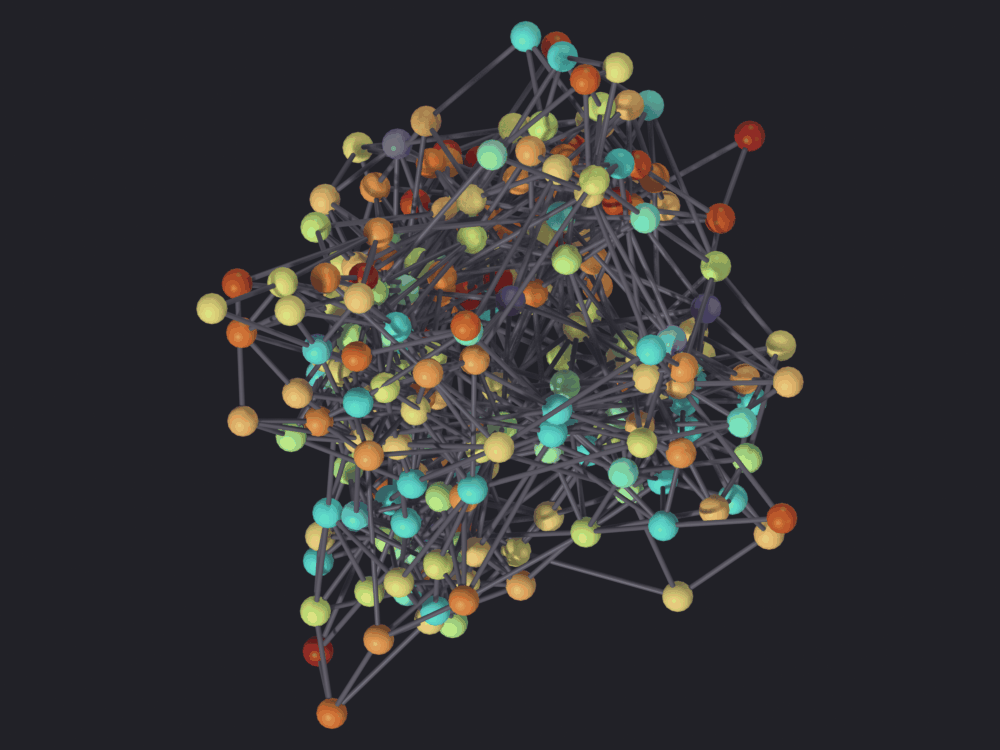

[PASS] 4_late_movement.png legible — 26.6% ink (healthy range 0.5–60%)


In [29]:
def mesh_drift(obj):
    """How far the drawn mesh has got from `node_positions`, in Blender units.

    `frame_set` rather than `view_layer.update()`, and that distinction is why
    this is a silent failure: an update does not re-evaluate the action, so the
    mesh reads correct until something does (a frame change, or a render).
    Measured on this graph: 0.0 after the update, four Blender units after the
    frame is set to the frame it was already on.
    """
    scene = bpy.context.scene
    scene.frame_set(scene.frame_current)
    mesh = np.empty(len(obj.data.vertices) * 3, dtype=np.float32)
    obj.data.vertices.foreach_get("co", mesh)
    return float(np.abs(positions(obj) - mesh.reshape(-1, 3)).max())


animated = (graph.animation_data is not None,
            graph.data.animation_data is not None)
drift_before = mesh_drift(graph)

if graph.animation_data:
    graph.animation_data_clear()
if graph.data.animation_data:
    graph.data.animation_data_clear()
geometry.update_node_positions_from_property(graph)
geometry.rebuild_edges(graph)

drift_after = mesh_drift(graph)
print(f"animation left on (object, mesh) : {animated}")
print(f"property vs drawn mesh, before   : {drift_before:.3f} Blender units")
print(f"                        after    : {drift_after:.3f}")

check("the mesh agrees with the positions again",
      drift_after < 1e-5,
      "without this the render is framed on one layout and drawn from "
      "another")

draw(graph, "renders/14_layouts/4_late_movement",
     look='ink', color_attribute="node_late_move", clip_high_pct=98)

> **Before you reach for the animated version.**
> `execute_layout_iteration`'s spring branch is a Python double loop over all
> node pairs, so it is quadratic *and* interpreted: 60 steps on 240 nodes took
> the time printed above, and the cost goes as the square of the node count.
> `SciGraphs/core/mesh/layouts/simulation.py` is the vectorized replacement, a
> `ForceSim` that keeps its state in NumPy arrays, splits repulsion into an
> exact near field and a gridded far field, and can be stepped the same way.
> Its `step()` returns total displacement rather than an energy: displacement
> is what the adaptive integrator already computes and what a viewer sees.

In [30]:
from scigraphs_core.mesh.layouts import simulation

edges = np.array(list(G.edges()), dtype=np.int64)
sim = simulation.ForceSim(simulation.random_positions(G.number_of_nodes(),
                          scale=5.0, seed=7),
                          edges, seed=7, scale=5.0)
started = time.time()
trace = [(sim.iteration + 10, sim.step(10)) for _ in range(6)]
sim_elapsed = time.time() - started
print(f"ForceSim: {STEPS} steps in {sim_elapsed:.3f} s, against "
      f"{elapsed:.1f} s for the same {STEPS} steps through the operator's own "
      f"path ({elapsed / max(sim_elapsed, 1e-6):.0f}x)")
for iteration, moved in trace:
    print(f"   iteration {iteration:>3}   moved {moved:8.2f}")

check("the vectorized simulator converges too",
      trace[-1][1] < trace[0][1] / 3,
      "and its movement per step is a real signal, not a cooling curve")

ForceSim: 60 steps in 0.024 s, against 6.6 s for the same 60 steps through the operator's own path (271x)
   iteration  10   moved   152.94
   iteration  20   moved    55.61
   iteration  30   moved    30.75
   iteration  40   moved    16.71
   iteration  50   moved    13.04
   iteration  60   moved    11.56
[PASS] the vectorized simulator converges too — and its movement per step is a real signal, not a cooling curve


True

## 6 · 2D against 3D

Every figure in this suite is a top-down orthographic plan. That is the right
default for a map (notebook 13 sets out why) but it means a 3D layout is
being **projected**, and the projection is not free: two nodes at the same
(x, y) and different z are drawn on top of each other, and the axis the
layout worked hardest to use is the one the camera throws away. The `hidden`
column of the panel table is that cost measured, at the radius each panel is
drawn with.

In [31]:
print(f"{'algorithm':<14}{'z share':>9}{'hidden in plan':>16}")
print("-" * 40)
for algorithm, s in sorted(panel_stats.items(), key=lambda kv: kv[1]['hidden']):
    print(f"{algorithm:<14}{s['z_share']:9.3f}{s['hidden']:>15.1%}")

flat = [a for a, s in panel_stats.items() if s['z_share'] < 0.05]
deep = [a for a, s in panel_stats.items() if s['hidden'] > 0.25]
print(f"\nessentially flat : {', '.join(flat)}")
print(f"over a quarter of the nodes hidden : {', '.join(deep)}")

algorithm       z share  hidden in plan
----------------------------------------
YIFAN_HU          0.035           0.0%
GRAPHVIZ_DOT      0.000           0.0%
SPECTRAL_3D       0.333          19.2%
IGRAPH_FR         0.291          26.7%
RANDOM            0.304          27.5%
IGRAPH_KK         0.312          35.4%
SPHERE            0.333          36.2%

essentially flat : YIFAN_HU, GRAPHVIZ_DOT
over a quarter of the nodes hidden : RANDOM, IGRAPH_FR, IGRAPH_KK, SPHERE


`FORCEATLAS2` is not in that table but is the add-on's scene
default, the one the panel offers before anything has been chosen, and it is
three-dimensional: the default path produces a layout whose third axis a
top-down figure throws away.

In [32]:
pos_fa2, _ = apply(graph, 'FORCEATLAS2')
span = pos_fa2.max(axis=0) - pos_fa2.min(axis=0)
(_c, _s, _d, nn_fa2), _src = sg.render.measure(graph)
print(f"FORCEATLAS2 span   X {span[0]:.2f}  Y {span[1]:.2f}  Z {span[2]:.2f}")
print(f"  the discarded axis is {span[2] / span[:2].max() * 100:.0f}% "
      f"of the longest axis the camera keeps")
print(f"  z share {z_share(pos_fa2):.3f}, "
      f"hidden in plan {plan_occlusion(pos_fa2, nn_fa2 * sg.render.NODE_FRACTION):.1%}")
print(f"  block ratio  3D {block_ratio(pos_fa2, block):.3f}   "
      f"flattened {block_ratio(np.column_stack([pos_fa2[:, :2], np.zeros(len(pos_fa2))]), block):.3f}")

Computing ForceAtlas2 (3D, networkx) for 240 nodes...
  ForceAtlas2 completed in 0.18s

Layout algorithm: FORCEATLAS2
Fallback: using SPRING (2D fallback) instead
   Reason: FORCEATLAS2 library not available
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: FORCEATLAS2
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.184s
Status: success (with fallback)

Info: Layout 'FORCEATLAS2' applied
FORCEATLAS2 span   X 9.19  Y 7.26  Z 8.01
  the discarded axis is 87% of the longest axis the camera keeps
  z share 0.287, hidden in plan 28.7%
  block ratio  3D 0.365   flattened 0.369


`IGRAPH_KK` hides 35 % of its nodes and `GRAPHVIZ_DOT` none,
and the difference is entirely the third axis: `dot` is planar (z share
0.000), `YIFAN_HU` in its default `2Z` mode nearly so (0.031), and the
genuinely three-dimensional layouts sit near 0.3. In the Kamada-Kawai panel
one entire block is drawn underneath its neighbor and does not appear in the
figure at all.

**When is a 3D layout worth it?** When the extra axis buys separation the
plane cannot give, which is measurable: compare each layout's block ratio
against that of its *projection* onto z = 0, which is what the reader of a
plan sees.

In [33]:
print(f"{'algorithm':<14}{'ratio in 3D':>13}{'ratio in plan':>15}{'cost':>8}")
print("-" * 52)
for algorithm in PANELS:
    pos, _ = apply(graph, algorithm)
    if pos is None:
        continue
    flat_pos = pos.copy()
    flat_pos[:, 2] = 0.0
    r3, r2 = block_ratio(pos, block), block_ratio(flat_pos, block)
    print(f"{algorithm:<14}{r3:13.3f}{r2:15.3f}{r2 - r3:+8.3f}")

algorithm       ratio in 3D  ratio in plan    cost
----------------------------------------------------

Layout algorithm: RANDOM
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: RANDOM
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.001s
Status: success

Info: Layout 'RANDOM' applied
RANDOM                1.003          1.005  +0.003
Computing igraph Fruchterman-Reingold layout for 240 nodes...
  Fruchterman-Reingold completed in 0.01s

Layout algorithm: IGRAPH_FR
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: IGRAPH_FR
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.012s
Status: success

Info: Layout 'IGRAPH_FR' applied
IGRAPH_FR             0.447          0.460  +0.014
Computing Yifan Hu layout for 240 nodes...
  mode=2Z, backend=scigraphs-utils, engine=sfdp
  z_method=SPECTRAL, z_scale=0.30000001192092896
  Generated Graphviz Z via SPECTRAL: -0.750 to 0.212
  scigraphs-utils Gr

The projection costs *little* on this measure. `YIFAN_HU` and
`GRAPHVIZ_DOT` lose nothing, having had nothing in Z to lose. The genuinely
three-dimensional layouts lose between 0.003 and 0.014, a few percent of the
structure they found, against 27 to 35 percent of their nodes hidden behind
another one. `FORCEATLAS2`, the default, throws away an axis 87 % as long as
the one the camera keeps and pays 0.004 for it.

`SPHERE` moves the other way: its ratio *improves* by 0.14 when flattened,
because the projection collapses the far hemisphere onto the near one and the
index-ordered bands overlap into something that looks even more grouped. A
number that gets better when information is destroyed is measuring the wrong
thing, and this is the second time `SPHERE` has scored well by accident.

So the case for three dimensions is rarely the printed figure: the structure
survives the projection nearly intact and a third of the nodes do not. It is
the viewport, where the graph can be turned, and the export, where the
coordinates are the deliverable. For a plan, `sfdp` in `2Z` mode is the
add-on's compromise: a true 2D layout with a Z derived from the spectrum, so
the plan loses nothing and the third axis is there to orbit.

> **Add-on defect: three layouts build their structure in the
> wrong plane.** Blender's up axis is Z. `_circular_hierarchy_layout` writes
> `y = 0` and lays its concentric rings out in **XZ**
> (`SciGraphs/core/mesh/layouts/hierarchical.py:298-303`), so a top-down
> camera sees a straight line: measured below, a Y extent of exactly zero.
> `_hierarchical_layout_3d` (`hierarchical.py:66-77`), `_spiral_layout_3d`
> and `_helix_layout` (`basic.py:57-65`, `:83-91`) use the same Y-up
> convention for their level or height axis, so their structure is also
> side-on in a plan.

In [34]:
for algorithm in ('CIRCULAR_HIERARCHY', 'HIERARCHICAL_3D', 'HELIX'):
    pos, _ = apply(graph, algorithm)
    span = pos.max(axis=0) - pos.min(axis=0)
    print(f"{algorithm:<20} X {span[0]:6.2f}   Y {span[1]:6.2f}   "
          f"Z {span[2]:6.2f}")

pos_circ, _ = apply(graph, 'CIRCULAR_HIERARCHY')
check("CIRCULAR_HIERARCHY has no extent at all in the plan's Y axis",
      float(pos_circ[:, 1].max() - pos_circ[:, 1].min()) < 1e-9,
      "a top-down render of it is a line")

Computing Circular Hierarchy layout for 240 nodes...
  Circular Hierarchy layout completed in 0.00s

Layout algorithm: CIRCULAR_HIERARCHY
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: CIRCULAR_HIERARCHY
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.004s
Status: success

Info: Layout 'CIRCULAR_HIERARCHY' applied
CIRCULAR_HIERARCHY   X   9.98   Y   0.00   Z   9.99
Computing Hierarchical 3D layout for 240 nodes...
  Hierarchical 3D completed in 0.00s

Layout algorithm: HIERARCHICAL_3D
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: HIERARCHICAL_3D
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 0.001s
Status: success

Info: Layout 'HIERARCHICAL_3D' applied
HIERARCHICAL_3D      X   5.00   Y  10.00   Z   5.00

Layout algorithm: HELIX
Graph: 240 nodes, 840 edges
Parameters:
  - algorithm: HELIX
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 240
  - num_edges: 840
Execution time: 

True

## 7 · Scale

The growth of layout cost with graph size decides which algorithms are
usable. Three sizes, six algorithms, the same Watts-Strogatz construction at
each size so the density is held constant.

The graphs are built and thrown away one at a time: a 3,000-node mesh with
9,000 edges is cheap, but leaving three of them in the scene would put them
in every subsequent render.

In [35]:
SIZES = (200, 800, 3000)
TIMED = ['SPECTRAL_3D', 'IGRAPH_FR', 'YIFAN_HU', 'GRAPHVIZ_SFDP',
         'IGRAPH_KK', 'SPRING_3D']

# Smallest size only: one `GRAPHVIZ_CIRCO` run on section 4's denser 240-node
# graph takes nearly four minutes, longer than the rest of this notebook
# together.
SLOW = ['CIRCLE_PACKING', 'GRAPHVIZ_CIRCO']

def best_of(obj, algorithm, repeats=3, cheap=2.0):
    """Fastest of a few runs, but only while a run is cheap.

    A single measurement of a layout that takes twenty milliseconds is mostly
    noise: the same call came out at 0.03 s and 0.12 s in two runs of this
    notebook, a factor of four in a growth column trying to show a factor of
    fifteen. The minimum of three removes that; the guard stops the same
    discipline costing ninety seconds where one run is already unambiguous.
    """
    _pos, seconds = apply(obj, algorithm)
    while repeats > 1 and seconds < cheap:
        _pos, again = apply(obj, algorithm)
        seconds = min(seconds, again)
        repeats -= 1
    return seconds


timings = {}
for n in SIZES:
    Gn = nx.connected_watts_strogatz_graph(n, 6, 0.08, seed=3)
    with nb.quiet():
        with bpy.context.temp_override(collection=COLL):
            probe = geometry.create_graph_object(GraphData(list(Gn.nodes()),
                                                 list(Gn.edges())))
    probe.name = f"Scale_{n}"
    for algorithm in TIMED:
        timings[(n, algorithm)] = best_of(probe, algorithm)
    if n == SIZES[0]:
        for algorithm in SLOW:
            timings[(n, algorithm)] = best_of(probe, algorithm)
    bpy.data.objects.remove(probe, do_unlink=True)
    print(f"  {n} nodes done")

print()
header = "".join(f"{n:>12}" for n in SIZES)
print(f"{'algorithm':<16}{header}{'growth':>12}")
print("-" * (16 + 12 * len(SIZES) + 12))
for algorithm in TIMED:
    row = "".join(f"{timings[(n, algorithm)]:>11.2f}s" for n in SIZES)
    first, last = timings[(SIZES[0], algorithm)], timings[(SIZES[-1], algorithm)]
    growth = last / first if first > 1e-4 else float("nan")
    print(f"{algorithm:<16}{row}{growth:>11.0f}x")

print(f"\nthe graph grew {SIZES[-1] / SIZES[0]:.0f}x; "
      f"quadratic cost would be {(SIZES[-1] / SIZES[0]) ** 2:.0f}x")
print(f"\nat {SIZES[0]} nodes only, because one run is more than the rest of "
      f"the table costs together:")
for algorithm in SLOW:
    seconds = timings[(SIZES[0], algorithm)]
    print(f"  {algorithm:<16}{seconds:8.1f}s"
          f"   ({seconds / timings[(SIZES[0], 'GRAPHVIZ_SFDP')]:.0f}x "
          f"GRAPHVIZ_SFDP on the same graph)")


Creating graph object with 200 nodes...
  Random positions generated in 0.00s (seed=1426602425)
  Vertices created in 0.00s
  600 edges created in 0.00s
  Mesh conversion in 0.00s
  Object created in 0.00s
Total graph creation time: 0.00s
Computing Spectral 3D layout for 200 nodes...
  Spectral 3D completed in 0.02s

Layout algorithm: SPECTRAL_3D
Graph: 200 nodes, 600 edges
Parameters:
  - algorithm: SPECTRAL_3D
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 200
  - num_edges: 600
Execution time: 0.021s
Status: success

Info: Layout 'SPECTRAL_3D' applied
Computing Spectral 3D layout for 200 nodes...
  Spectral 3D completed in 0.02s

Layout algorithm: SPECTRAL_3D
Graph: 200 nodes, 600 edges
Parameters:
  - algorithm: SPECTRAL_3D
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 200
  - num_edges: 600
Execution time: 0.021s
Status: success

Info: Layout 'SPECTRAL_3D' applied
Computing Spectral 3D layout for 200 nodes...
  Spectral 3D completed in 0.02s

Layout algorithm: SPECTR

Read the last column against the two numbers under the table:
the graph grew fifteen-fold, so a linear cost would show about 15x and a
quadratic one about 225x.

* **Sub-linear, and not even monotone.** `SPECTRAL_3D` is *faster at 800
  nodes than at 200*, and that is real rather than noise: these are the best
  of three runs. `nx.spectral_layout` uses a dense `eigh` on the full
  Laplacian below 500 nodes and a sparse ARPACK solve at or above it
  (networkx's `drawing/layout.py:1098`, "dense solver is faster for small
  graphs"), and on this shape of graph the crossover is in the wrong place.
  Section 4 showed why its figure keeps it from being the answer.
* **Near-linear, and compiled.** `YIFAN_HU` and `GRAPHVIZ_SFDP` are the same
  multilevel engine: coarsen the graph, lay out the small version, refine.
  Both land near the linear line. `IGRAPH_FR` grows faster but is still under
  two seconds at 3,000 nodes. These three survive a graph of a hundred
  thousand.
* **Quadratic.** `SPRING_3D` and `IGRAPH_KK` come out at or above the
  quadratic line: `nx.spring_layout` is interpreted Python over all pairs,
  and Kamada-Kawai needs the all-pairs shortest-path matrix, O(n²) in memory
  before it is anything in time. Both are right for a few hundred nodes and
  wrong above a few thousand.

The two at the bottom are on their own scale: about two thousand times `sfdp`
on the same two hundred nodes. `GRAPHVIZ_CIRCO` lays each biconnected
component out on its own circle, close to its worst case on a graph that is
one large biconnected blob; `CIRCLE_PACKING` is an iterative Koebe
construction. Both are strongly density-dependent: the denser 240-node graph
of section 4 costs `circo` nearly four times what this 200-node one does.
Neither belongs inside a loop over parameters.

## 8 · The trap: sfdp and isolated nodes

Not an exception you can catch, and why section 1 checks the graph for
isolated nodes before doing anything else.

The Graphviz bundled in `scigraphs-utils` is built **with asserts live** (no
`NDEBUG`). Its `sfdp` post-processing smoothers compute, per node, an average
distance over the node's neighbors and assert that the count is positive. A
node with no neighbor other than itself (degree 0, or nothing but a
self-loop) leaves that count at zero, and Graphviz calls `abort()`, which
from a C library takes the whole Blender process with it: no traceback, no
`except`, no partial result. The kernel dies and an unsaved scene is gone.
Measured, the process exits with **signal 6 (SIGABRT), status 134**, on a
graph of five nodes.

The unsafe smoothing values are `spring` (the add-on's default), `avg_dist`,
`graph_dist` and `power_dist`. `none`, `triangle` and `rng` are safe. It is
not a size problem: four nodes with one isolated aborts, and a connected
graph of eight hundred is fine.

In [36]:
G_holes = nx.connected_watts_strogatz_graph(60, 4, 0.1, seed=5)
G_holes.add_nodes_from([60, 61, 62])          # three nodes with no edges
G_holes = nx.convert_node_labels_to_integers(G_holes, ordering="sorted")

with nb.quiet():
    with bpy.context.temp_override(collection=COLL):
        holed = geometry.create_graph_object(GraphData(list(G_holes.nodes()),
                                             list(G_holes.edges())))
holed.name = "With_Isolated_Nodes"
put_attribute(holed, "node_degree",
              np.array([d for _, d in sorted(G_holes.degree())],
              dtype=np.float32))

seen_holes, _ = _build_networkx_graph(holed)
print(f"isolated nodes as the layout sees them: "
      f"{sum(1 for _, d in seen_holes.degree() if d == 0)}")
print(f"_has_isolated_node says: {_has_isolated_node(seen_holes)}")
print(f"default smoothing      : "
      f"{bpy.context.scene.scigraphs.sfdp_smoothing}")


Creating graph object with 63 nodes...
  Random positions generated in 0.00s (seed=1426602425)
  Vertices created in 0.00s
  120 edges created in 0.00s
  Mesh conversion in 0.00s
  Object created in 0.00s
Total graph creation time: 0.00s
isolated nodes as the layout sees them: 3
_has_isolated_node says: True
default smoothing      : spring


The add-on carries a guard, worth watching fire rather than
trusting: `_scigraphs_utils_graphviz_layout` downgrades the smoothing to
`none` when the graph has an isolated node
(`SciGraphs/core/mesh/layouts/yifan_hu.py:152`). The console line below is
the guard reporting itself; without it this cell would end the session.

In [37]:
sg.graphs.activate(holed)
result = bpy.ops.scigraphs.apply_layout(algorithm='YIFAN_HU',
                                        iterations=50, scale=5.0)
print("apply_layout ->", result)

check("sfdp survived a graph with isolated nodes",
      'FINISHED' in result,
      "the guard downgraded smoothing from 'spring' to 'none'")

Computing Yifan Hu layout for 63 nodes...
  mode=2Z, backend=scigraphs-utils, engine=sfdp
  z_method=SPECTRAL, z_scale=0.30000001192092896
  Isolated node detected - sfdp smoothing 'spring' would abort Graphviz, falling back to 'none'
  Generated Graphviz Z via SPECTRAL: -0.675 to 0.750
  scigraphs-utils Graphviz sfdp computed 63 nodes
  Z range: -0.675 to 0.750
  Final ranges (scale=5.0): X=5.0, Y=4.7, Z=1.4
  Yifan Hu (scigraphs-utils sfdp, mode=2Z) completed in 0.01s

Layout algorithm: YIFAN_HU
Graph: 63 nodes, 120 edges
Parameters:
  - algorithm: YIFAN_HU
  - iterations: 50
  - scale: 5.0000
  - num_nodes: 63
  - num_edges: 120
Execution time: 0.008s
Status: success

Info: Layout 'YIFAN_HU' applied
apply_layout -> {'FINISHED'}
[PASS] sfdp survived a graph with isolated nodes — the guard downgraded smoothing from 'spring' to 'none'


True

Three things this does *not* protect you from:

1. **The guard is on the operator path only.** Calling
   `scigraphs_utils.graphviz_layout(..., smoothing='spring')` directly, with
   an isolated node, aborts. Nothing in this notebook does that, deliberately.
2. **The guard has been lost before.** It was written, never committed, and
   wiped by a `git reset` two days later; the crash came straight back,
   including in the installed extension copy, so reinstalling would not have
   rescued it. Verify it in whatever copy Blender is loading, not in the
   working tree: those are different files (see the note in
   `notebooks/README.md` about the installed copy).
3. **The same build has no triangulation library.** `overlap='prism'`, the
   default of `sfdp_overlap`, prints an error and silently does nothing, and
   `triangle` and `rng` smoothing are believed to no-op for the same reason.
   Check the build can honor an overlap quality setting before chasing it in
   the panel.

The rule: **drop isolated nodes before an sfdp layout, or pick a different
engine.** `neato` and `fdp` are unaffected; both were run against the same
graph and returned normally.

In [38]:
for algorithm in ('GRAPHVIZ_NEATO', 'GRAPHVIZ_FDP'):
    pos, seconds = apply(holed, algorithm)
    print(f"{algorithm:<16} {'FINISHED' if pos is not None else 'FAILED':<10}"
          f"{seconds:6.2f} s")

largest = G_holes.subgraph(max(nx.connected_components(G_holes), key=len))
print(f"\nor drop them: {G_holes.number_of_nodes()} nodes -> "
      f"{largest.number_of_nodes()} in the largest component")

  scigraphs-utils Graphviz neato computed 63 nodes

Layout algorithm: GRAPHVIZ_NEATO
Graph: 63 nodes, 120 edges
Parameters:
  - algorithm: GRAPHVIZ_NEATO
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 63
  - num_edges: 120
Execution time: 0.007s
Status: success

Info: Layout 'GRAPHVIZ_NEATO' applied
GRAPHVIZ_NEATO   FINISHED    0.01 s
  scigraphs-utils Graphviz fdp computed 63 nodes

Layout algorithm: GRAPHVIZ_FDP
Graph: 63 nodes, 120 edges
Parameters:
  - algorithm: GRAPHVIZ_FDP
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 63
  - num_edges: 120
Execution time: 0.007s
Status: success

Info: Layout 'GRAPHVIZ_FDP' applied
GRAPHVIZ_FDP     FINISHED    0.01 s

or drop them: 63 nodes -> 60 in the largest component


The graph that survived, laid out by the `sfdp` run the guard
rescued, colored by degree, which separates out the three nodes this section
is about.

Computing Yifan Hu layout for 63 nodes...
  mode=2Z, backend=scigraphs-utils, engine=sfdp
  z_method=SPECTRAL, z_scale=0.30000001192092896
  Isolated node detected - sfdp smoothing 'spring' would abort Graphviz, falling back to 'none'
  Generated Graphviz Z via SPECTRAL: -0.750 to 0.675
  scigraphs-utils Graphviz sfdp computed 63 nodes
  Z range: -0.750 to 0.675
  Final ranges (scale=5.0): X=5.0, Y=4.7, Z=1.4
  Yifan Hu (scigraphs-utils sfdp, mode=2Z) completed in 0.01s

Layout algorithm: YIFAN_HU
Graph: 63 nodes, 120 edges
Parameters:
  - algorithm: YIFAN_HU
  - iterations: 100
  - scale: 5.0000
  - num_nodes: 63
  - num_edges: 120
Execution time: 0.008s
Status: success

Info: Layout 'YIFAN_HU' applied
Info: Geometry Nodes modifier added
Info: Attribute -> node_degree  ·  node_degree -> turbo [log]  [0 … 5] on Point


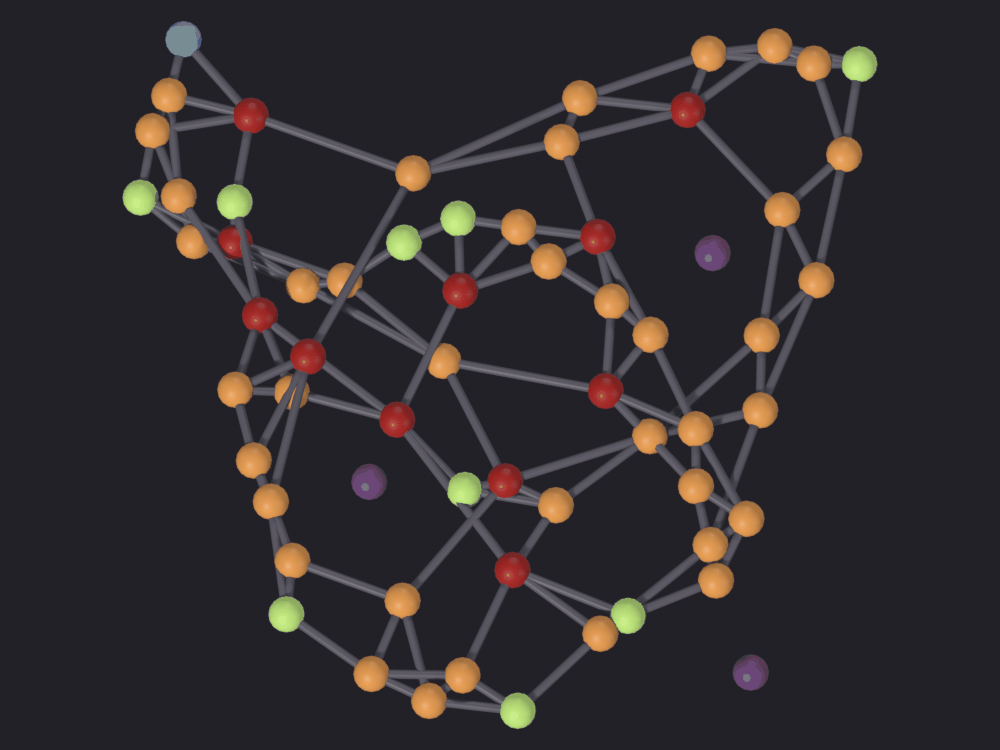

[PASS] 5_isolated_nodes.png legible — 16.9% ink (healthy range 0.5–60%)


In [39]:
apply(holed, 'YIFAN_HU')
draw(holed, "renders/14_layouts/5_isolated_nodes",
     look='ink', color_attribute="node_degree")

The three purple nodes are the isolated ones: degree 0, sitting
in the gaps of a network they are not part of. A force layout has nothing to
say about where they belong, because the only thing that would say it is an
edge, so they are placed by repulsion alone, wherever there is room. Honest,
but in the figure indistinguishable from a genuinely peripheral node, which
is the other reason to drop them before the layout.

## Other operators in this panel

Two more layout operators sit next to `apply_layout`, and neither does what
its label suggests.

`scigraphs.reset_layout` returns the graph to random positions, drawn with a
bare `np.random.rand`
(`SciGraphs/ui/operators/scigraphs/layout_operators.py:478`), not through
`get_geometry_seed()` the way the mesh builder does. So "reset" does not
return the positions the graph was created with, and two resets do not agree
with each other. It also clears the object's animation data, the part you
want after an `execute_layout_step` run has keyframed sixty frames of
positions onto it.

`scigraphs.network_splitter_3d` moves nodes, but as a post-process: it takes
an existing layout and separates it into Z layers by community, degree or an
attribute. It belongs with the topology material of notebook 05.

In [40]:
before_reset = positions(graph).copy()
sg.graphs.activate(graph)
with nb.quiet():
    bpy.ops.scigraphs.reset_layout()
after_one = positions(graph).copy()
with nb.quiet():
    bpy.ops.scigraphs.reset_layout()
after_two = positions(graph).copy()

check("reset_layout does not reproduce itself",
      float(np.abs(after_one - after_two).max()) > 1e-6,
      "two resets, two different sets of positions")

Info: Layout reset to random positions
Info: Layout reset to random positions
[PASS] reset_layout does not reproduce itself — two resets, two different sets of positions


True

## Rendering

Every figure is EEVEE through `nb.figure()`, `look='ink'`,
top-down and orthographic, colored by `node_block` for the comparisons and
by `node_shift`, `node_late_move` or `node_degree` where the subject is the
layout itself. Section 1 covers the ramp and the per-panel node radius;
notebook 13 the render path, notebook 16 what turbo costs a reader. The
panels hold the graph, attribute, colormap, resolution and camera fixed, and
are still not comparable in size.

> The Vulkan warning applies here as everywhere: on Blender's Vulkan backend,
> the default on Linux, `gpu.state.point_size_set` is a no-op for the add-on's
> shaders, so `POINT` and `DISK` nodes come out one pixel wide. Start Blender
> with `--gpu-backend opengl` for any render you intend to look at.

## Save

In [41]:
out_dir = nb.out("02_layouts")
out_dir.mkdir(parents=True, exist_ok=True)

# `stochastic_block_model` leaves the partition on the graph as a list of sets,
# and GraphML has no type for that.
export = nx.Graph()
export.add_nodes_from((n, {"block": int(block[n])}) for n in G.nodes())
export.add_edges_from(G.edges())
nx.write_graphml(export, out_dir / "sbm_240.graphml")

import csv

with open(out_dir / "layout_comparison.csv", "w", newline="",
          encoding="utf-8") as handle:
    writer = csv.writer(handle)
    writer.writerow(["algorithm", "seconds", "extent_bu", "median_nn_bu",
                    "node_radius_bu", "block_ratio", "hidden_in_plan",
                    "z_share"])
    for algorithm, s in panel_stats.items():
        writer.writerow([algorithm, f"{s['seconds']:.3f}", f"{s['extent']:.4f}",
                        f"{s['median_nn']:.5f}", f"{s['radius']:.5f}",
                        f"{s['ratio']:.4f}", f"{s['hidden']:.4f}",
                        f"{s['z_share']:.4f}"])

with open(out_dir / "layout_timings.csv", "w", newline="",
          encoding="utf-8") as handle:
    writer = csv.writer(handle)
    writer.writerow(["nodes", "algorithm", "seconds"])
    for (n, algorithm), seconds in timings.items():
        writer.writerow([n, algorithm, f"{seconds:.3f}"])

print("written to", nb.rel(out_dir))
for path in sorted(out_dir.iterdir()):
    print("  ", path.name, f"{path.stat().st_size / 1e3:.0f} kB")

written to notebooks/out/02_layouts
   layout_comparison.csv 1 kB
   layout_timings.csv 0 kB
   sbm_240.graphml 47 kB


## Summary

| Question | Answer, as measured here |
|---|---|
| Does a layout repeat? | Only `FORCEATLAS2` among the force layouts; `IGRAPH_KK`, `SPECTRAL_3D`, `MDS_3D`, `GRAPHVIZ_DOT`, `GRID`, `SPHERE` and `RANDOM` are deterministic outright |
| Does the seed matter? | It moves the picture (median residual ≈ 0.5 RMS radii after alignment) and not the finding (block ratio agrees to three decimals) |
| Does `scale` mean anything? | Not across algorithms: extent 5.4 to 140 Blender units at the same `scale=5.0` |
| What does a plan cost a 3D layout? | 27 to 35 % of the nodes hidden behind another, and 0.003 to 0.014 of the structure score. `SPHERE` is the exception: it improves by 0.14, which is why that score cannot be trusted for it |
| What scales? | `sfdp` / `YIFAN_HU`, `IGRAPH_FR`, `SPECTRAL_3D`: sub-second at 3,000 nodes. `SPRING_3D` and `IGRAPH_KK` are quadratic |
| What will crash? | `sfdp` with default smoothing on a graph containing an isolated node: `abort()`, status 134, no exception |
| What will be lost? | Every `EDGE`-domain attribute, on every layout, silently zeroed. Lay out first, measure the edges second |

**The rule the notebook argues for:** a layout is part of the method, not
part of the presentation. Report which algorithm, which parameters and which
seed, and quote a measurement over the *relations* rather than a description
of the picture.

Next: **17 · Centrality**, which puts a number on each node and needs a
layout to show it, so it inherits everything above.